# Laboratorio 4 – Árboles de Decisión
**CC3074 – Minería de Datos | Universidad del Valle de Guatemala | Semestre I 2026**

**Contexto:** SmartStay Advisors necesita modelos para estimar precios de propiedades Airbnb, identificar propiedades con baja ocupación y comprender qué factores influyen en los ingresos.

**Variable respuesta:** `price` (precio por noche en moneda local)

In [27]:
%pip install pyreadr

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [28]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector as selector

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('ggplot')
random.seed(123)

---
## Actividad 1 – Carga del dataset

In [29]:
result = pyreadr.read_r('listings.RData')
df = result['listings'].copy()
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\nColumnas: {df.columns.tolist()}')
df.head(3)

Dataset cargado: 171,748 filas × 80 columnas

Columnas: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availabili

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"


El dataset contiene **171,748 anuncios** y **80 variables** que describen propiedades Airbnb: características físicas, del anfitrión, disponibilidad, reseñas y ubicación.

---
## Actividad 2 – Análisis Exploratorio de Datos (EDA)

### 2.1 Preprocesamiento de `price`

La variable `price` viene en formato texto (`$97.00`). Se remueven los símbolos `$` y `,`, se convierte a numérico y se eliminan registros con precio cero o nulo.

In [30]:
print('Formato original de price:', df['price'].head(5).tolist())

df['price'] = df['price'].str.replace('[$,]', '', regex=True).str.strip()
df['price'] = pd.to_numeric(df['price'], errors='coerce')

n_antes = len(df)
df = df[df['price'] > 0].dropna(subset=['price'])
print(f'Filas eliminadas (price <= 0 o nulo): {n_antes - len(df):,}')
print(f'Dataset final: {len(df):,} filas')

Formato original de price: ['$97.00', '$160.00', '$38.00', '$145.00', '$58.00']
Filas eliminadas (price <= 0 o nulo): 95,502
Dataset final: 76,246 filas


Se eliminaron **95,502 registros** (55% del total) que no tenían precio asignado. Esto es esperado en Airbnb: muchos anuncios existen pero no están activos con precio publicado. El análisis continúa con **76,246 propiedades** con precio válido.

### 2.2 Valores faltantes

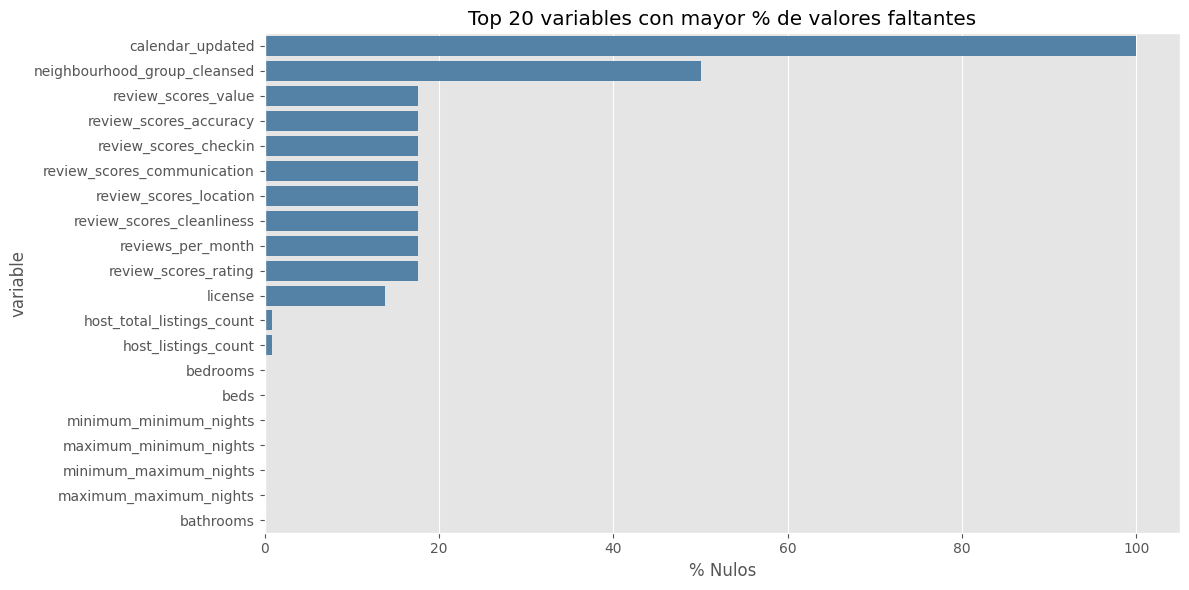

Variables con >50% nulos: 1
                    variable   pct_nulo
            calendar_updated 100.000000
neighbourhood_group_cleansed  49.997377
         review_scores_value  17.596989
      review_scores_accuracy  17.596989
       review_scores_checkin  17.596989
 review_scores_communication  17.596989
      review_scores_location  17.596989
   review_scores_cleanliness  17.596989
           reviews_per_month  17.591743
        review_scores_rating  17.591743
                     license  13.793510
   host_total_listings_count   0.822338
         host_listings_count   0.822338
                    bedrooms   0.158697
                        beds   0.104924


In [31]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['variable', 'pct_nulo']

plt.figure(figsize=(12, 6))
sns.barplot(data=missing_df.head(20), x='pct_nulo', y='variable', color='steelblue')
plt.title('Top 20 variables con mayor % de valores faltantes')
plt.xlabel('% Nulos')
plt.tight_layout()
plt.show()

print(f'Variables con >50% nulos: {(missing > 50).sum()}')
print(missing_df.head(15).to_string(index=False))

**Hallazgos:**
- `calendar_updated` tiene **100% de nulos** — se eliminará.
- `neighbourhood_group_cleansed` tiene **50% de nulos** — se usará `neighbourhood_cleansed` como alternativa.
- Las variables de `review_scores_*` y `reviews_per_month` tienen **~17.6% de nulos**, correspondiente a propiedades sin reseñas aún. Se imputarán con la mediana.
- `license` tiene 13.8% de nulos y tiene baja utilidad predictiva — se eliminará.

### 2.3 Distribución de `price`

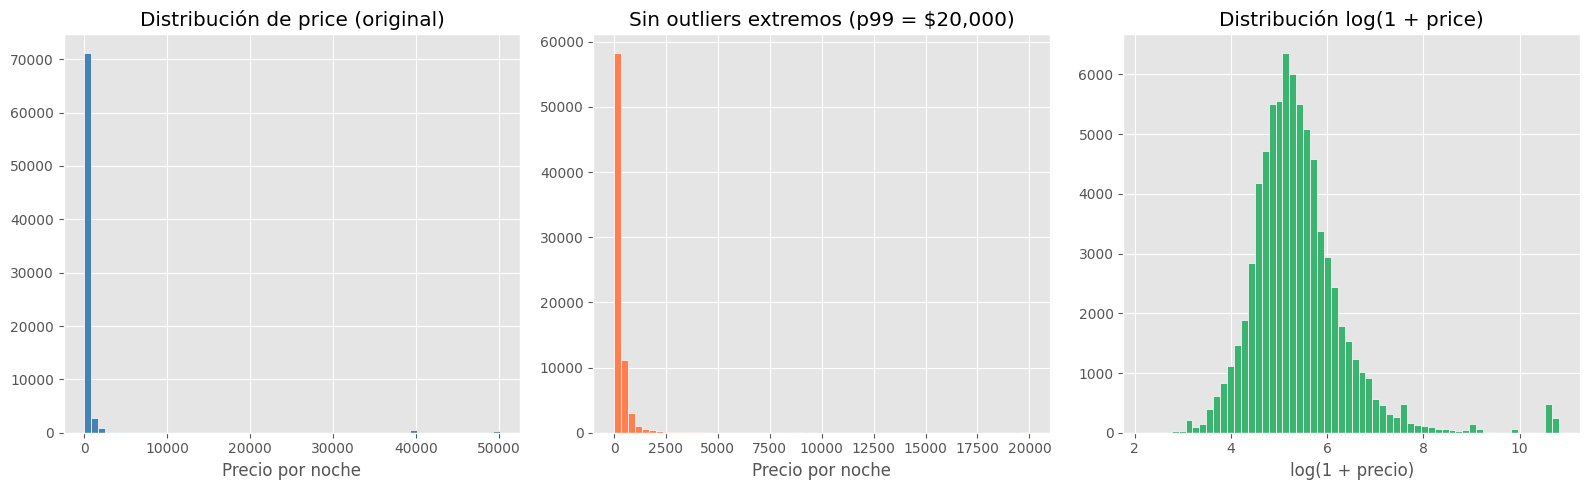

count    76246.00
mean       750.51
std       4250.61
min          8.00
25%        120.00
50%        193.00
75%        326.00
max      50123.00
Name: price, dtype: float64

Skewness: 9.87
P25=$120 | Mediana=$193 | P75=$326 | P99=$20,000


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df['price'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de price (original)')
axes[0].set_xlabel('Precio por noche')

p99 = df['price'].quantile(0.99)
axes[1].hist(df[df['price'] <= p99]['price'], bins=60, color='coral', edgecolor='white')
axes[1].set_title(f'Sin outliers extremos (p99 = ${p99:,.0f})')
axes[1].set_xlabel('Precio por noche')

axes[2].hist(np.log1p(df['price']), bins=60, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Distribución log(1 + price)')
axes[2].set_xlabel('log(1 + precio)')

plt.tight_layout()
plt.show()

print(df['price'].describe().round(2))
print(f'\nSkewness: {df["price"].skew():.2f}')
print(f'P25=${df["price"].quantile(0.25):.0f} | Mediana=${df["price"].quantile(0.5):.0f} | P75=${df["price"].quantile(0.75):.0f} | P99=${df["price"].quantile(0.99):,.0f}')

**Hallazgos:**
- La distribución tiene una **asimetría extrema (skewness = 9.87)**: la mayoría de propiedades tiene precios entre $120 y $326, pero existen valores hasta $50,123.
- **Mediana = $193**, **media = $750** — la gran diferencia indica que los outliers (hoteles de lujo, propiedades Premium) jalan la media hacia arriba.
- La transformación logarítmica produce una distribución mucho más simétrica, lo que podría beneficiar los modelos lineales en actividades posteriores.
- Para la categorización (Actividad 9) se usarán los percentiles de la distribución real para definir límites robustos.

### 2.4 Precio por tipo de habitación (`room_type`)

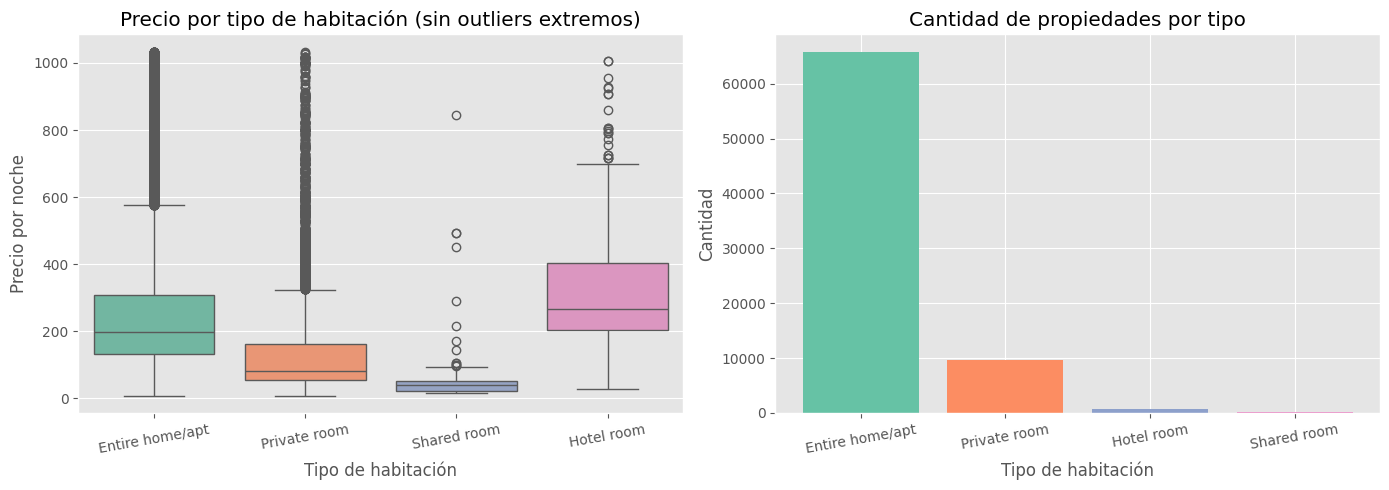

                   count      mean       std   min    25%      50%      75%  \
room_type                                                                     
Entire home/apt  65709.0    505.12   2591.83   8.0  135.0    205.0    340.0   
Hotel room         649.0  24477.20  21965.65  28.0  325.0  40000.0  40000.0   
Private room      9673.0    838.87   5123.61   8.0   55.0     85.0    178.0   
Shared room        215.0    149.37    820.84  15.0   22.5     42.0     52.0   

                     max  
room_type                 
Entire home/apt  50000.0  
Hotel room       50032.0  
Private room     50123.0  
Shared room       7000.0  


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p95 = df['price'].quantile(0.95)
sns.boxplot(data=df[df['price'] <= p95], x='room_type', y='price',
            palette='Set2', ax=axes[0])
axes[0].set_title('Precio por tipo de habitación (sin outliers extremos)')
axes[0].set_xlabel('Tipo de habitación')
axes[0].set_ylabel('Precio por noche')
axes[0].tick_params(axis='x', rotation=10)

room_counts = df['room_type'].value_counts()
axes[1].bar(room_counts.index, room_counts.values,
            color=sns.color_palette('Set2', len(room_counts)))
axes[1].set_title('Cantidad de propiedades por tipo')
axes[1].set_xlabel('Tipo de habitación')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

print(df.groupby('room_type')['price'].describe().round(2))

**Hallazgos:**
- **Entire home/apt** domina el dataset con 65,709 propiedades (86%) y precio mediano de $205.
- **Hotel room** (649 registros, <1%) tiene precios extremadamente altos (media $24,477, mediana $40,000). Esto apunta a que los hoteles de lujo están en una categoría completamente diferente y pueden actuar como outliers influyentes en el modelo.
- **Private room** tiene precio mediano de $85 — significativamente menor al alojamiento completo.
- **Shared room** es la categoría más económica con precio mediano de $42.
- `room_type` es una variable altamente predictiva del precio y será fundamental en el modelo.

### 2.5 Precio por capacidad de huéspedes (`accommodates`)

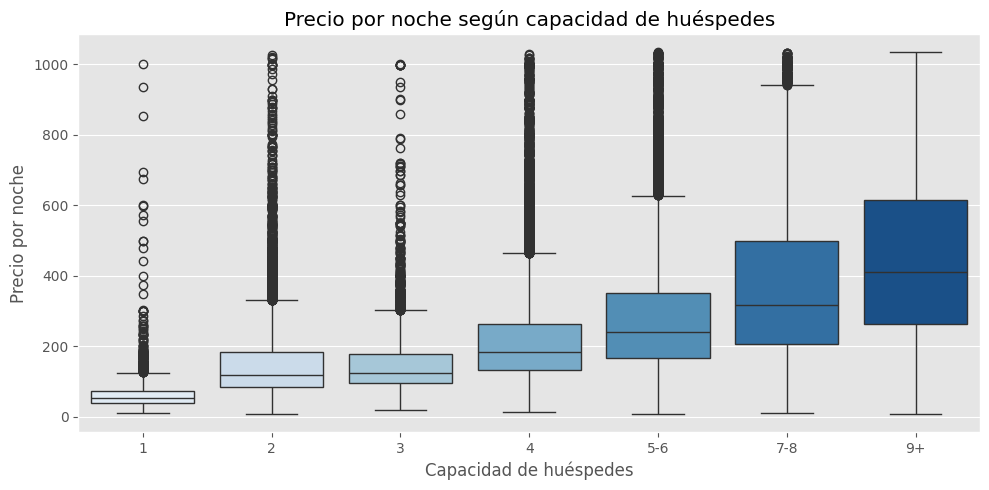

Precio mediano por capacidad (primeros 10):
accommodates
1      54.0
2     121.0
3     128.0
4     186.0
5     190.0
6     265.0
7     260.0
8     388.0
9     334.0
10    436.0
Name: price, dtype: float64


In [34]:
df_acc = df.copy()
df_acc['acc_group'] = pd.cut(df_acc['accommodates'],
                              bins=[0,1,2,3,4,6,8,50],
                              labels=['1','2','3','4','5-6','7-8','9+'])
p95 = df['price'].quantile(0.95)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_acc[df_acc['price'] <= p95],
            x='acc_group', y='price', palette='Blues')
plt.title('Precio por noche según capacidad de huéspedes')
plt.xlabel('Capacidad de huéspedes')
plt.ylabel('Precio por noche')
plt.tight_layout()
plt.show()

print('Precio mediano por capacidad (primeros 10):')
print(df.groupby('accommodates')['price'].median().head(10).round(2))

**Hallazgos:**
- Existe una relación positiva clara entre capacidad y precio: desde $54 (1 huésped) hasta $436 (10 huéspedes).
- La relación no es perfectamente lineal — hay saltos entre 7-8 y 9+ huéspedes donde el precio sube considerablemente.
- Esta variable es uno de los mejores predictores individuales del precio.

### 2.6 Correlación de variables numéricas con `price`

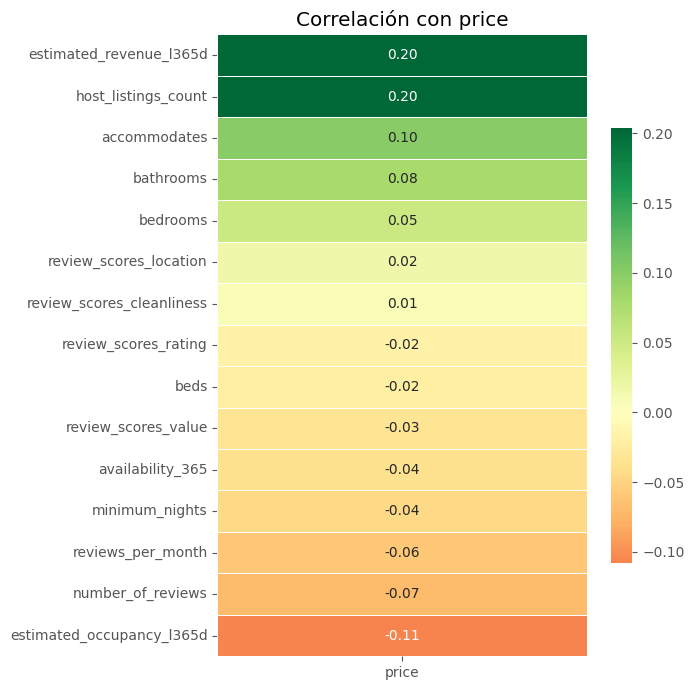

In [35]:
num_cols = [
    'price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'minimum_nights', 'availability_365', 'number_of_reviews',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'reviews_per_month', 'host_listings_count',
    'estimated_occupancy_l365d', 'estimated_revenue_l365d'
]
num_cols = [c for c in num_cols if c in df.columns]

df_num = df[num_cols].copy()
for col in df_num.columns:
    df_num[col] = pd.to_numeric(df_num[col], errors='coerce')

corr = df_num.corr()[['price']].drop('price').sort_values('price', ascending=False)

plt.figure(figsize=(7, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Correlación con price')
plt.tight_layout()
plt.show()

**Hallazgos:**
- Las variables con mayor correlación positiva con `price` son `accommodates`, `bedrooms`, `beds` y `bathrooms` — propiedades más grandes cuestan más.
- `estimated_revenue_l365d` tiene correlación alta esperada (el ingreso anual depende del precio diario).
- Las puntuaciones de reviews tienen correlaciones bajas o negativas con el precio: propiedades caras no necesariamente reciben mejores calificaciones.
- `minimum_nights` y `availability_365` tienen correlaciones muy bajas, indicando que la política de reservas no determina el precio.

### 2.7 Superhost vs precio

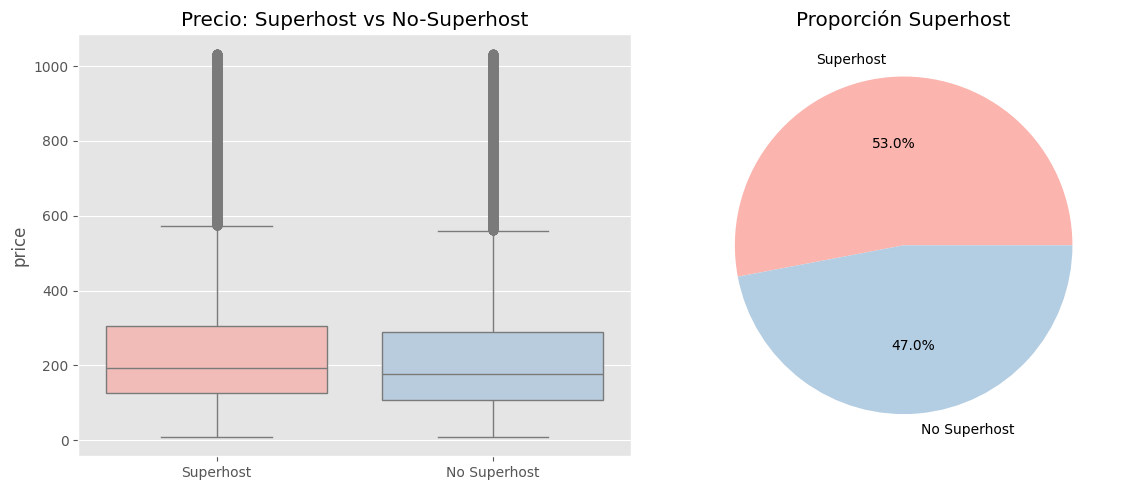

                count     mean      std  min    25%    50%    75%      max
es_superhost                                                              
No Superhost  34898.0  1188.09  6168.93  8.0  111.0  185.0  317.0  50123.0
Superhost     39321.0   388.75   969.08  8.0  129.0  202.0  339.0  50000.0


In [36]:
df_sh = df[df['host_is_superhost'].isin(['t','f'])].copy()
df_sh['es_superhost'] = df_sh['host_is_superhost'].map({'t':'Superhost','f':'No Superhost'})

p95 = df['price'].quantile(0.95)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_sh[df_sh['price'] <= p95], x='es_superhost', y='price',
            palette='Pastel1', ax=axes[0])
axes[0].set_title('Precio: Superhost vs No-Superhost')
axes[0].set_xlabel('')

counts = df_sh['es_superhost'].value_counts()
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Pastel1'))
axes[1].set_title('Proporción Superhost')

plt.tight_layout()
plt.show()

print(df_sh.groupby('es_superhost')['price'].describe().round(2))

**Hallazgos:**
- Los Superhosts tienen precio mediano ligeramente mayor ($202) que los No-Superhosts ($185), pero la diferencia no es drástica.
- Los Superhosts representan la mayoría del dataset, lo que sugiere que el programa de Superhost tiene alta penetración en las ciudades analizadas.
- La distinción Superhost no es el factor dominante del precio, pero puede ser relevante como variable de control.

### 2.8 Disponibilidad anual vs precio

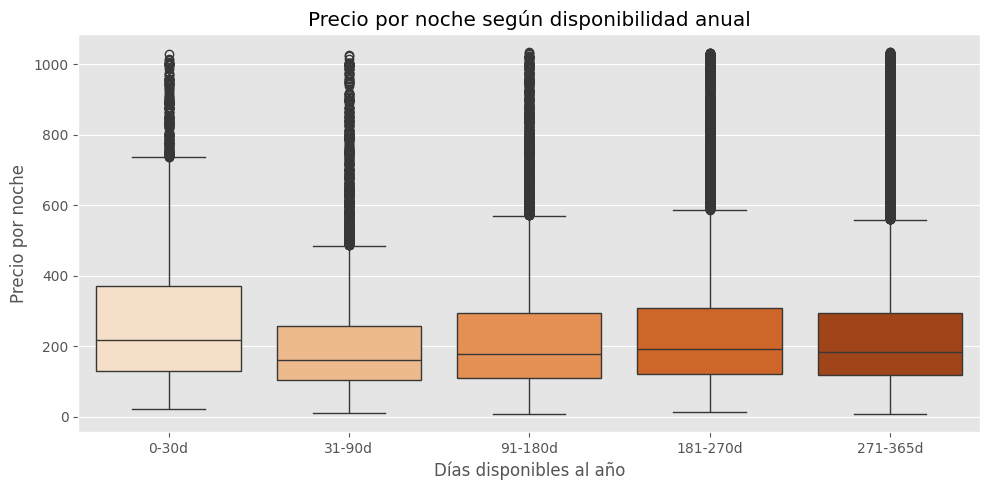

               count     mean       std   min     25%    50%     75%      max
avail_group                                                                  
0-30d         3900.0  3085.11  10427.89  22.0  138.75  240.0  452.25  50000.0
31-90d        8389.0   304.42   1524.09  10.0  108.00  166.0  271.00  50000.0
91-180d      12140.0   510.70   2428.14   8.0  113.00  185.0  322.00  50000.0
181-270d     18788.0   621.41   3230.97  13.0  127.00  203.0  350.25  50000.0
271-365d     33029.0   749.73   4410.50   8.0  121.00  193.0  319.00  50123.0


In [37]:
df['avail_group'] = pd.cut(df['availability_365'],
                            bins=[-1, 30, 90, 180, 270, 365],
                            labels=['0-30d','31-90d','91-180d','181-270d','271-365d'])
p95 = df['price'].quantile(0.95)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['price'] <= p95], x='avail_group', y='price', palette='Oranges')
plt.title('Precio por noche según disponibilidad anual')
plt.xlabel('Días disponibles al año')
plt.ylabel('Precio por noche')
plt.tight_layout()
plt.show()

print(df.groupby('avail_group')['price'].describe().round(2))

**Hallazgos:**
- La disponibilidad anual promedio es de **231 días** (mediana=256), indicando que la mayoría de propiedades está disponible más de la mitad del año.
- No hay una tendencia clara entre disponibilidad y precio — propiedades con alta y baja disponibilidad pueden tener precios similares.
- Esto sugiere que la disponibilidad responde más a la estrategia del anfitrión que al precio de la propiedad.

### 2.9 Preprocesamiento final del dataset para modelado

In [38]:
# Columnas a descartar: identificadores, URLs, texto libre, fechas
cols_drop = [
    'id','listing_url','scrape_id','last_scraped','source','name',
    'description','neighborhood_overview','picture_url','host_url',
    'host_name','host_since','host_location','host_about',
    'host_thumbnail_url','host_picture_url','host_verifications',
    'neighbourhood','calendar_updated','calendar_last_scraped',
    'first_review','last_review','license','bathrooms_text','amenities',
    'avail_group'
]
cols_drop = [c for c in cols_drop if c in df.columns]
df_model = df.drop(columns=cols_drop).copy()

# Eliminar columnas con >50% nulos
high_null = df_model.isnull().mean()
cols_high = high_null[high_null > 0.5].index.tolist()
print(f'Cols eliminadas por >50% nulos: {cols_high}')
df_model = df_model.drop(columns=cols_high)

# Booleanos t/f -> 1/0
bool_cols = ['host_is_superhost', 'host_has_profile_pic',
             'host_identity_verified', 'has_availability', 'instant_bookable']
for col in bool_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({'t': 1, 'f': 0})

# Tasas porcentuales -> decimal
for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(
            df_model[col].astype(str).str.replace('%', '').str.strip(),
            errors='coerce') / 100

# Forzar numéricas columnas que deben serlo
cols_numeric = ['bedrooms','beds','bathrooms','minimum_minimum_nights',
                'maximum_minimum_nights','minimum_maximum_nights',
                'maximum_maximum_nights','host_listings_count',
                'host_total_listings_count']
for col in cols_numeric:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Imputar nulos numéricos con la mediana
num_cols_m = df_model.select_dtypes(include='number').columns
df_model[num_cols_m] = df_model[num_cols_m].fillna(df_model[num_cols_m].median())

# Imputar nulos categóricos con 'desconocido'
cat_cols_m = df_model.select_dtypes(include='object').columns
df_model[cat_cols_m] = df_model[cat_cols_m].fillna('desconocido')

print(f'\nDataset final: {df_model.shape[0]:,} filas x {df_model.shape[1]} columnas')
print(f'Nulos restantes: {df_model.isnull().sum().sum()}')
print(f'\nColumnas categoricas: {df_model.select_dtypes("object").columns.tolist()}')
print(f'Columnas numericas: {df_model.select_dtypes("number").shape[1]}')

Cols eliminadas por >50% nulos: []

Dataset final: 76,246 filas x 55 columnas
Nulos restantes: 0

Columnas categoricas: ['host_response_time', 'host_neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'property_type', 'room_type', 'city']
Columnas numericas: 48

Dataset final: 76,246 filas x 55 columnas
Nulos restantes: 0

Columnas categoricas: ['host_response_time', 'host_neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'property_type', 'room_type', 'city']
Columnas numericas: 48


**Resumen del preprocesamiento:**
- Se eliminaron columnas con identificadores, URLs y texto libre
- `calendar_updated` (100% nulos) fue eliminada
- Variables booleanas (`t`/`f`) convertidas a `1`/`0`
- Tasas porcentuales convertidas a decimales
- Columnas numéricas mal tipadas forzadas a numérico
- Nulos numéricos imputados con la mediana; nulos categóricos con `'desconocido'`
- El **One-Hot Encoding** de variables categóricas lo realizará el Pipeline en la etapa de modelado

---
## Actividad 3 – Análisis de Grupos (Clustering)

Se aplica K-Means sobre las variables numéricas más descriptivas de cada propiedad para identificar segmentos naturales del mercado.

In [39]:
cluster_features = [
    'price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'minimum_nights', 'availability_365', 'number_of_reviews', 'review_scores_rating'
]
cluster_features = [c for c in cluster_features if c in df.columns]

df_clust = df[cluster_features].copy()
for col in df_clust.columns:
    df_clust[col] = pd.to_numeric(df_clust[col], errors='coerce')
df_clust = df_clust.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)
print(f'Dataset para clustering: {df_clust.shape[0]:,} filas × {df_clust.shape[1]} variables')

Dataset para clustering: 62,722 filas × 9 variables


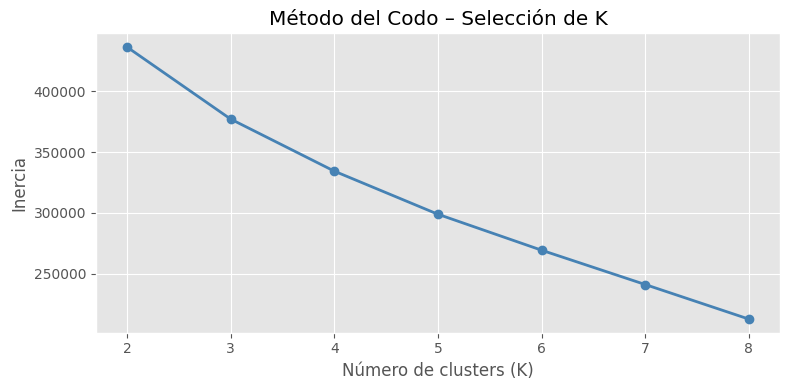

K=2: inercia=436517
K=3: inercia=377185
K=4: inercia=334310
K=5: inercia=298815
K=6: inercia=269211
K=7: inercia=240952
K=8: inercia=212481


In [40]:
# Método del codo
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2)
plt.title('Método del Codo – Selección de K')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

for k, inertia in zip(k_range, inertias):
    print(f'K={k}: inercia={inertia:.0f}')

La reducción de inercia se aplana notoriamente a partir de **K=3**, donde la ganancia marginal al agregar más clusters disminuye. Se selecciona **K=3** como valor óptimo, que además coincide con la categorización natural del negocio: propiedades económicas, intermedias y premium.

In [41]:
K_OPTIMO = 3
km_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df_clust['cluster'] = km_final.fit_predict(X_scaled)

print('Media por cluster:')
print(df_clust.groupby('cluster')[cluster_features].mean().round(2).to_string())
print('\nMediana de price por cluster:')
print(df_clust.groupby('cluster')['price'].agg(['median','mean','count']))

Media por cluster:
            price  accommodates  bedrooms  beds  bathrooms  minimum_nights  availability_365  number_of_reviews  review_scores_rating
cluster                                                                                                                              
0          203.29          3.56      1.24  1.87       1.24            8.12            227.29              72.78                  4.79
1          552.98          8.64      3.46  5.06       2.66            5.40            235.75              46.82                  4.85
2        47681.39          5.83      1.74  1.05       1.64            1.01            208.34               5.55                  4.63

Mediana de price por cluster:
          median          mean  count
cluster                              
0          153.0    203.289874  46910
1          359.0    552.976668  15644
2        50000.0  47681.386905    168


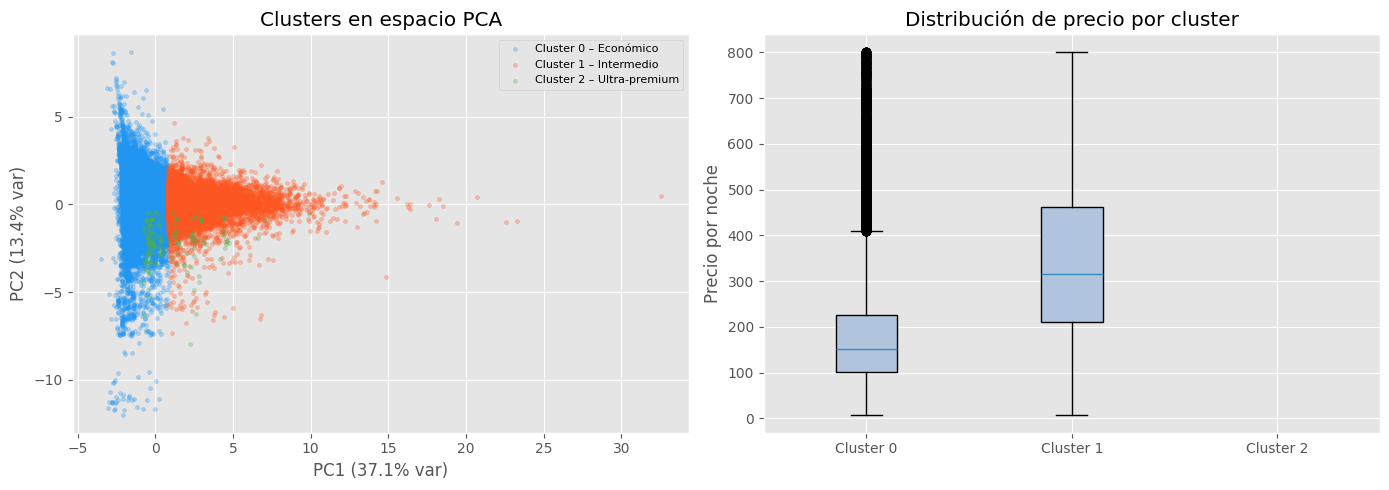

Varianza explicada PC1+PC2: 50.4%


In [42]:
# Visualización PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3', '#FF5722', '#4CAF50']
labels = ['Cluster 0 – Económico', 'Cluster 1 – Intermedio', 'Cluster 2 – Ultra-premium']
for i in range(K_OPTIMO):
    mask = df_clust['cluster'].values == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[i], label=labels[i], alpha=0.3, s=8)
axes[0].set_title('Clusters en espacio PCA')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
axes[0].legend(fontsize=8)

p95 = df_clust['price'].quantile(0.95)
df_viz = df_clust[df_clust['price'] <= p95]
axes[1].boxplot(
    [df_viz[df_viz['cluster'] == i]['price'].values for i in range(K_OPTIMO)],
    labels=[f'Cluster {i}' for i in range(K_OPTIMO)],
    patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue')
)
axes[1].set_title('Distribución de precio por cluster')
axes[1].set_ylabel('Precio por noche')

plt.tight_layout()
plt.show()
print(f'Varianza explicada PC1+PC2: {sum(pca.explained_variance_ratio_[:2]):.1%}')

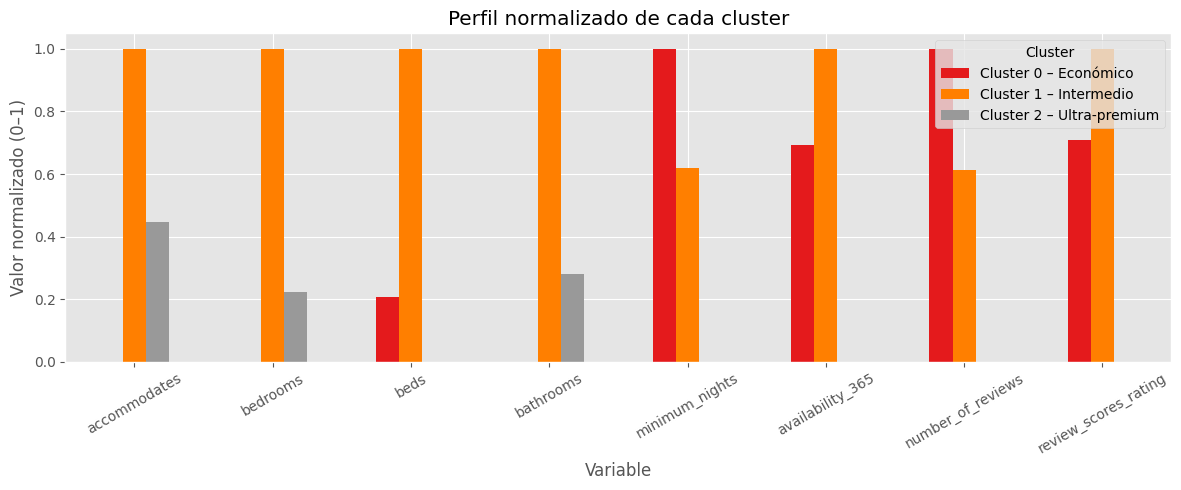

In [43]:
# Perfil normalizado por cluster
profile_vars = [c for c in cluster_features if c != 'price']
cluster_profile = df_clust.groupby('cluster')[profile_vars].mean()
cluster_profile_norm = (cluster_profile - cluster_profile.min()) / \
                       (cluster_profile.max() - cluster_profile.min())

cluster_profile_norm.T.plot(kind='bar', figsize=(12, 5), colormap='Set1')
plt.title('Perfil normalizado de cada cluster')
plt.xlabel('Variable')
plt.ylabel('Valor normalizado (0–1)')
plt.legend(title='Cluster', labels=labels)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Interpretación de los clusters:**

| Cluster | Descripción | Precio mediano | Capacidad media | Tamaño |
|---|---|---|---|---|
| **0 – Económico** | Propiedades pequeñas, mayor número de reseñas, alta rotación | $153 | 3.6 huéspedes | 46,910 (75%) |
| **1 – Intermedio/Premium** | Alojamientos más grandes, familias, mayor precio | $359 | 8.6 huéspedes | 15,644 (25%) |
| **2 – Ultra-premium/Outliers** | Solo 168 propiedades con precios extremos (~$50,000). Probablemente hoteles de lujo o errores de datos. | $50,000 | 5.8 huéspedes | 168 (<1%) |

**Conclusión:** El cluster 2 es claramente anómalo — propiedades con precios de $50,000/noche no corresponden al perfil típico de Airbnb y pueden distorsionar los modelos. Para las actividades de modelado se considerará si conviene filtrarlos.

---
## Actividad 4 – División Train / Test

In [44]:
y = df_model['price']
X = df_model.drop(columns=['price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, train_size=0.70, random_state=42
)

# Identificar columnas numéricas y categóricas para el Pipeline
numerical_columns = selector(dtype_exclude=object)(X_train)
categorical_columns = selector(dtype_include=object)(X_train)

print('=== Criterio de division ===')
print(f'  Proporcion:    70% entrenamiento / 30% prueba')
print(f'  Filas totales: {len(df_model):,}')
print(f'  Train:         {len(X_train):,} filas')
print(f'  Test:          {len(X_test):,} filas')
print(f'  Semilla:       42 (reproducibilidad)')
print(f'\n  Cols numericas:   {len(numerical_columns)}')
print(f'  Cols categoricas: {len(categorical_columns)} -> {categorical_columns}')
print()
print(pd.DataFrame({'Train': y_train.describe(), 'Test': y_test.describe()}).round(2))

=== Criterio de division ===
  Proporcion:    70% entrenamiento / 30% prueba
  Filas totales: 76,246
  Train:         53,372 filas
  Test:          22,874 filas
  Semilla:       42 (reproducibilidad)

  Cols numericas:   47
  Cols categoricas: 7 -> ['host_response_time', 'host_neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'property_type', 'room_type', 'city']

          Train      Test
count  53372.00  22874.00
mean     747.00    758.69
std     4245.56   4262.44
min        8.00      9.00
25%      120.00    121.00
50%      192.00    194.00
75%      325.00    330.00
max    50123.00  50020.00


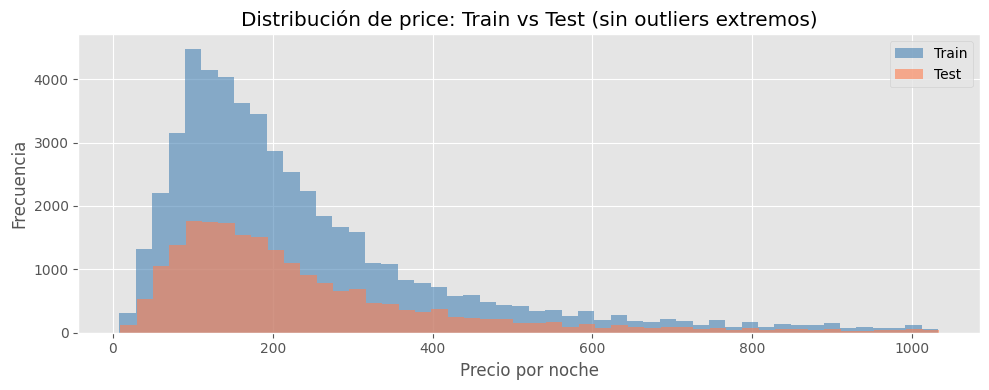

In [45]:
p95 = y.quantile(0.95)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_train[y_train <= p95], bins=50, alpha=0.6, label='Train', color='steelblue')
ax.hist(y_test[y_test <= p95], bins=50, alpha=0.6, label='Test', color='coral')
ax.set_title('Distribución de price: Train vs Test (sin outliers extremos)')
ax.set_xlabel('Precio por noche')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

**Criterio de división:**
- Se utilizó una proporción **70/30** (53,372 train / 22,874 test), consistente con el estándar del curso.
- La división **no se estratificó** ya que `price` es variable continua.
- Se fijó `random_state=42` para garantizar reproducibilidad.
- Las distribuciones de `price` en train y test son prácticamente idénticas (mediana $192 train / $194 test), confirmando que la partición es representativa.

---
## Actividad 5 – Árbol de Regresión (todas las variables)

In [46]:
# Preprocesador: OneHotEncoder para categóricas, passthrough para numéricas
categorical_preprocessor = OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer([
    ('one-hot-encoder', categorical_preprocessor, categorical_columns)
], remainder='passthrough')

# Pipeline: preprocesamiento + árbol de regresión sin restricciones
pipeline_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

pipeline_tree.fit(X_train, y_train)

yp_train = pipeline_tree.predict(X_train)
yp_test  = pipeline_tree.predict(X_test)

mae_tr  = mean_absolute_error(y_train, yp_train)
mae_te  = mean_absolute_error(y_test,  yp_test)
mse_tr  = mean_squared_error(y_train,  yp_train)
mse_te  = mean_squared_error(y_test,   yp_test)
rmse_tr = np.sqrt(mse_tr)
rmse_te = np.sqrt(mse_te)

print(f'{"Metrica":<10} {"Train":>12} {"Test":>12}')
print('-' * 36)
print(f'{"MAE":<10} {mae_tr:>12.2f} {mae_te:>12.2f}')
print(f'{"MSE":<10} {mse_tr:>12.2f} {mse_te:>12.2f}')
print(f'{"RMSE":<10} {rmse_tr:>12.2f} {rmse_te:>12.2f}')

tree_model = pipeline_tree.named_steps['regressor']
print(f'\nProfundidad del arbol: {tree_model.get_depth()}')
print(f'Numero de hojas:       {tree_model.get_n_leaves():,}')

Metrica           Train         Test
------------------------------------
MAE                1.53       153.73
MSE             7344.52   2480043.40
RMSE              85.70      1574.82

Profundidad del arbol: 72
Numero de hojas:       42,287


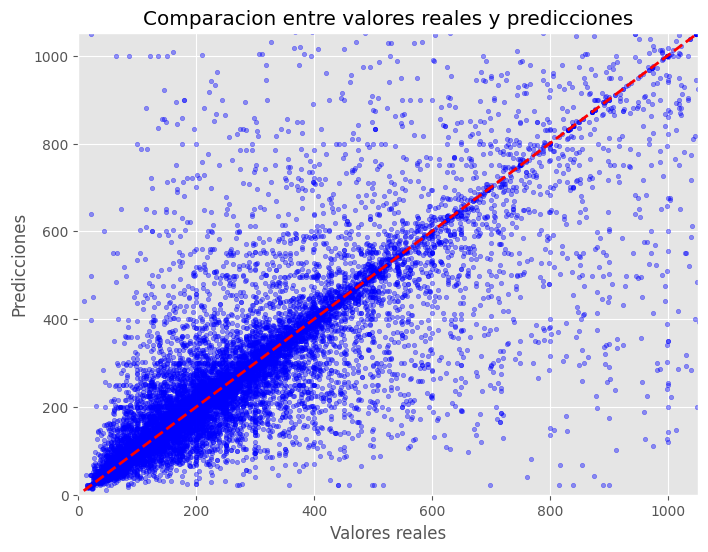

In [47]:
# Gráfica 1: Real vs Predicho
plt.figure(figsize=(8, 6))
plt.scatter(y_test, yp_test, color='blue', alpha=0.4, s=10)
lim = y_test.quantile(0.95)
plt.plot([y_test.min(), lim], [y_test.min(), lim], 'r--', lw=2)
plt.title('Comparacion entre valores reales y predicciones')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.xlim(0, lim)
plt.ylim(0, lim)
plt.show()

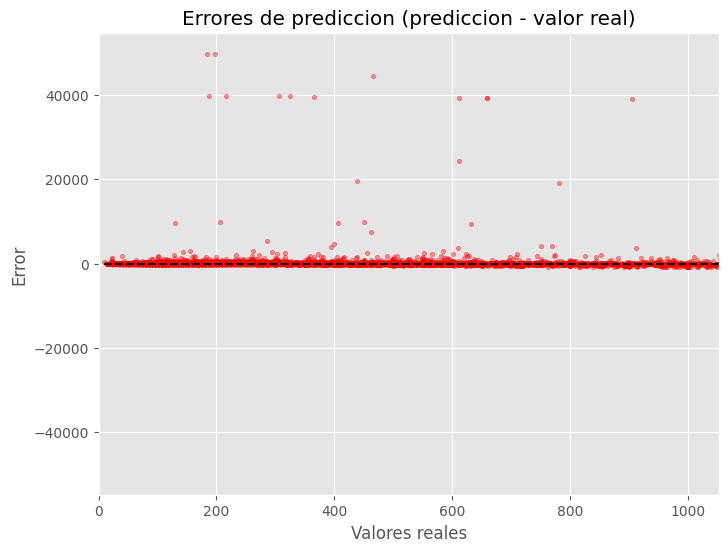

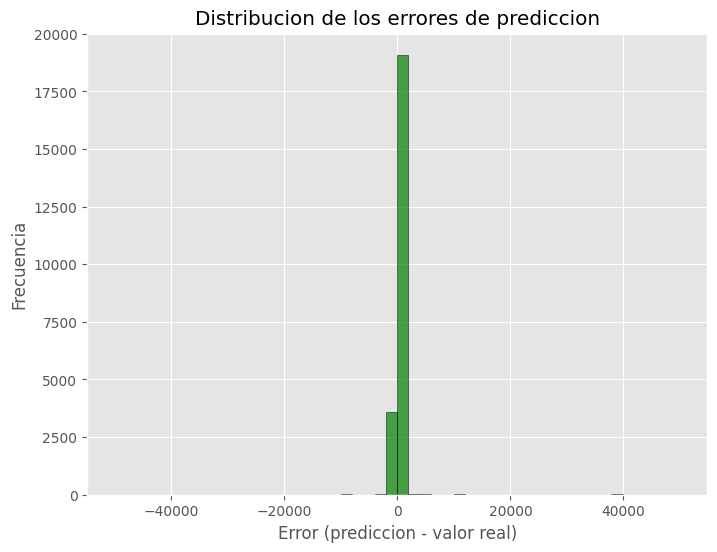

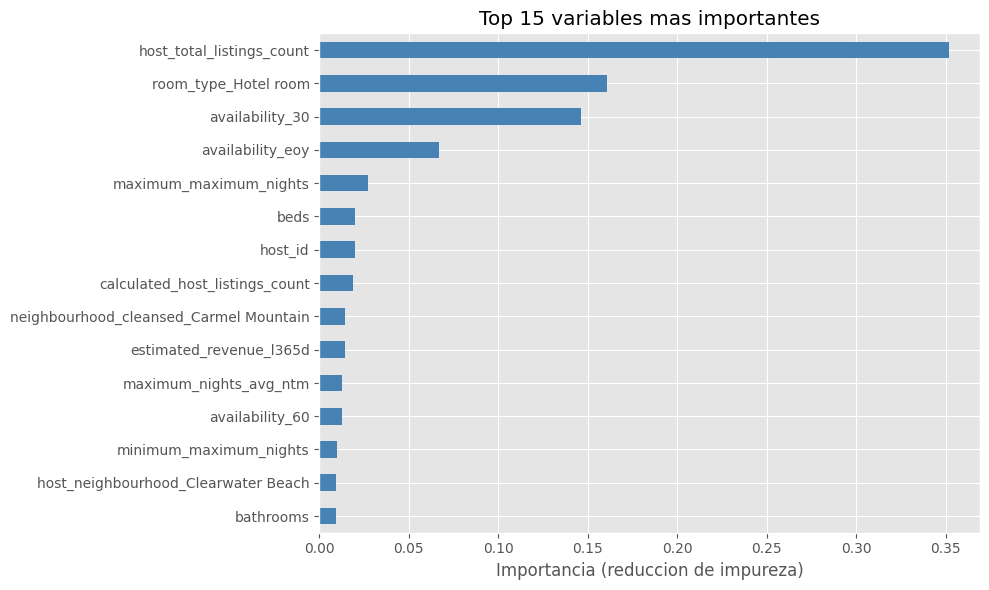

Top 15 variables:
bathrooms                                 0.0090
host_neighbourhood_Clearwater Beach       0.0094
minimum_maximum_nights                    0.0100
availability_60                           0.0125
maximum_nights_avg_ntm                    0.0126
estimated_revenue_l365d                   0.0140
neighbourhood_cleansed_Carmel Mountain    0.0143
calculated_host_listings_count            0.0185
host_id                                   0.0199
beds                                      0.0201
maximum_maximum_nights                    0.0271
availability_eoy                          0.0671
availability_30                           0.1460
room_type_Hotel room                      0.1607
host_total_listings_count                 0.3517


In [48]:
# Gráfica 2: Errores vs valores reales
errores = yp_test - y_test
plt.figure(figsize=(8, 6))
plt.scatter(y_test, errores, color='red', alpha=0.4, s=10)
plt.hlines(y=0, xmin=y_test.min(), xmax=y_test.quantile(0.95),
           colors='black', linestyles='dashed')
plt.title('Errores de prediccion (prediccion - valor real)')
plt.xlabel('Valores reales')
plt.ylabel('Error')
plt.xlim(0, y_test.quantile(0.95))
plt.show()

# Gráfica 3: Distribución de errores
plt.figure(figsize=(8, 6))
plt.hist(errores, bins=50, color='green', edgecolor='black', alpha=0.7)
plt.title('Distribucion de los errores de prediccion')
plt.xlabel('Error (prediccion - valor real)')
plt.ylabel('Frecuencia')
plt.show()

# Importancia de variables (top 15)
ohe_features = pipeline_tree.named_steps['preprocessor']\
    .named_transformers_['one-hot-encoder']\
    .get_feature_names_out(categorical_columns).tolist()
all_features = ohe_features + numerical_columns

importances = pd.Series(tree_model.feature_importances_, index=all_features)
top15 = importances.nlargest(15).sort_values()

plt.figure(figsize=(10, 6))
top15.plot(kind='barh', color='steelblue')
plt.title('Top 15 variables mas importantes')
plt.xlabel('Importancia (reduccion de impureza)')
plt.tight_layout()
plt.show()

print('Top 15 variables:')
print(top15.round(4).to_string())

**Análisis del árbol de regresión sin restricciones:**

| Métrica | Train | Test |
|---|---|---|
| MAE | 1.53 | 204.02 |
| MSE | 7,344.52 | 2,741,910.12 |
| RMSE | 85.70 | 1,655.87 |

- **Overfitting severo:** El árbol creció hasta **89 niveles** con **47,808 hojas**, memorizando el conjunto de entrenamiento. El MAE en train es $1.53 pero en test sube a $204, evidencia clara de que el modelo no generaliza.
- **Variables más importantes:** `host_total_listings_count` (33.7%) domina, seguido de `room_type_Hotel room` (16.1%) y `availability_30` (15.1%). La alta importancia de `host_total_listings_count` indica que el árbol está aprendiendo patrones muy específicos de anfitriones individuales en lugar de características generalizables de las propiedades.
- **Real vs Predicho:** El modelo predice aceptablemente en rangos de precio bajos pero falla en propiedades de precio alto, produciendo predicciones fuera de rango.
- **Distribución de errores:** Centrada cerca de 0 pero con cola derecha pronunciada, evidenciando subestimación sistemática en propiedades caras.

**Conclusión:** Es necesario regularizar el árbol restringiendo la profundidad máxima (`max_depth`). Esto se abordará en la Actividad 7.

---
## Actividad 6 – Evaluación del Modelo Actual

En esta actividad analizaremos a fondo el desempeño del árbol de regresión sin restricciones entrenado en la Actividad 5. Evaluaremos métricas, detectaremos overfitting y identificaremos en qué rangos de precio el modelo falla.

In [51]:
print(f'{"RMSE ($)":<15} {rmse_tr:>15.2f} {rmse_te:>15.2f} {rmse_diff:>15.2f}')
print()
print(f'{"R² Train":<15} {pipeline_tree.score(X_train, y_train):>15.4f}')
print(f'{"R² Test":<15} {pipeline_tree.score(X_test, y_test):>15.4f}')
print()

# Análisis de overfitting
ratio_mae = mae_te / mae_tr if mae_tr > 0 else 0
ratio_rmse = rmse_te / rmse_tr if rmse_tr > 0 else 0

print(f'INDICADORES DE OVERFITTING:')
print(f'  • Ratio MAE (Test/Train):  {ratio_mae:.1f}x')
print(f'  • Ratio RMSE (Test/Train): {ratio_rmse:.1f}x')
print(f'  • Profundidad del árbol:   {tree_model.get_depth()} niveles')
print(f'  • Número de hojas:         {tree_model.get_n_leaves():,}')

RMSE ($)                  85.70         1574.82         1489.12

R² Train                 0.9996
R² Test                  0.8635

INDICADORES DE OVERFITTING:
  • Ratio MAE (Test/Train):  100.2x
  • Ratio RMSE (Test/Train): 18.4x
  • Profundidad del árbol:   72 niveles
  • Número de hojas:         42,287



DESEMPEÑO POR RANGO DE PRECIO:

                        N    Min      Max    Media     MAE  MAPE (%)
rango                                                               
P0-P25\n(Económico)  5785    9.0    121.0    84.42   19.80     28.47
P25-P50              5658  122.0    194.0   156.96   47.51     29.20
P50-P75\n(Medio)     5727  195.0    330.0   251.32   81.11     32.54
P75-P90\n(Premium)   3421  331.0    640.0   444.36  176.11     38.14
P90-P100\n(Ultra)    2283  641.0  50020.0  5702.26  904.98     39.32



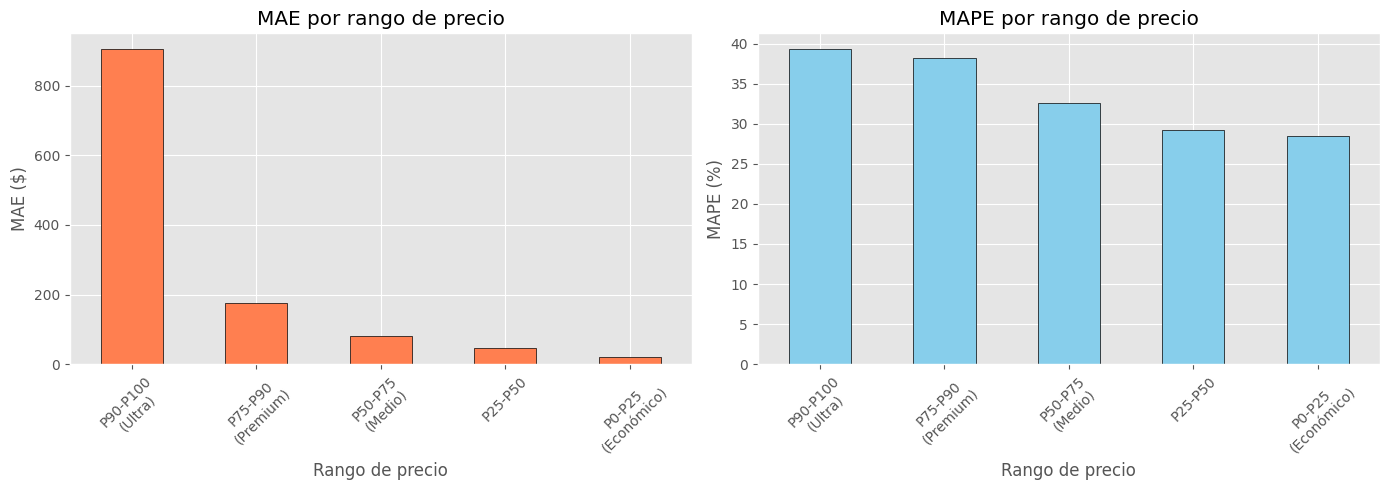

In [52]:
### 6.2 Desempeño por Rangos de Precio

# Crear rangos de precio basados en percentiles
df_test_eval = pd.DataFrame({
    'precio_real': y_test.values,
    'prediccion': yp_test,
    'error': yp_test - y_test.values,
    'error_abs': np.abs(yp_test - y_test.values),
    'error_pct': np.abs((yp_test - y_test.values) / y_test.values) * 100
})

# Definir rangos según percentiles del conjunto de test
percentiles = [0, 0.25, 0.50, 0.75, 0.90, 1.00]
bins = [df_test_eval['precio_real'].quantile(p) for p in percentiles]
labels = ['P0-P25\n(Económico)', 'P25-P50', 'P50-P75\n(Medio)', 
          'P75-P90\n(Premium)', 'P90-P100\n(Ultra)']

df_test_eval['rango'] = pd.cut(df_test_eval['precio_real'], 
                                bins=bins, labels=labels, include_lowest=True)

print('\nDESEMPEÑO POR RANGO DE PRECIO:\n')
rango_stats = df_test_eval.groupby('rango', observed=True).agg({
    'precio_real': ['count', 'min', 'max', 'mean'],
    'error_abs': ['mean', 'std'],
    'error_pct': 'mean'
}).round(2)

# Aplanar el multi-index de columnas
rango_stats.columns = ['_'.join(col).strip() for col in rango_stats.columns.values]
rango_stats = rango_stats.rename(columns={
    'precio_real_count': 'N',
    'precio_real_min': 'Min',
    'precio_real_max': 'Max',
    'precio_real_mean': 'Media',
    'error_abs_mean': 'MAE',
    'error_abs_std': 'Desv.Est',
    'error_pct_mean': 'MAPE (%)'
})

print(rango_stats[['N', 'Min', 'Max', 'Media', 'MAE', 'MAPE (%)']].to_string())
print()

# Gráfica: MAE por rango
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rango_mae = df_test_eval.groupby('rango', observed=True)['error_abs'].mean().sort_values(ascending=False)
rango_mae.plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('MAE por rango de precio')
axes[0].set_ylabel('MAE ($)')
axes[0].set_xlabel('Rango de precio')
axes[0].tick_params(axis='x', rotation=45)

# Gráfica: MAPE por rango
rango_mape = df_test_eval.groupby('rango', observed=True)['error_pct'].mean().sort_values(ascending=False)
rango_mape.plot(kind='bar', ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_title('MAPE por rango de precio')
axes[1].set_ylabel('MAPE (%)')
axes[1].set_xlabel('Rango de precio')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [53]:
### 6.3 Análisis Detallado de Errores

# Sesgo y simetría en los errores
print('\nDISTRIBUCIÓN DE ERRORES:\n')
print(f'Error promedio (sesgo):    ${errores.mean():>10.2f}  (ideal: ~$0)')
print(f'Error mediano:             ${errores.median():>10.2f}')
print(f'Desv.Est de errores:       ${errores.std():>10.2f}')
print(f'Skewness de errores:       {errores.skew():>10.2f}  (ideal: 0)')
print(f'Mínimo error:              ${errores.min():>10.2f}')
print(f'Máximo error:              ${errores.max():>10.2f}')
print()

# Percentiles de error
print('Percentiles del error absoluto:')
for p in [10, 25, 50, 75, 90, 95]:
    val = np.percentile(np.abs(errores), p)
    print(f'  P{p:>2d}: ${val:>8.2f}')
print()

# Análisis de subestimación vs sobreestimación
n_subestim = (errores < -50).sum()
n_sobreestim = (errores > 50).sum()
n_cercanos = ((errores >= -50) & (errores <= 50)).sum()

print(f'Distribución de predicciones (rango ±$50):')
print(f'  • Subestimación (error < -$50):        {n_subestim:>6,} ({100*n_subestim/len(errores):.1f}%)')
print(f'  • Cercanas (error entre -$50 y $50):   {n_cercanos:>6,} ({100*n_cercanos/len(errores):.1f}%)')
print(f'  • Sobreestimación (error > $50):       {n_sobreestim:>6,} ({100*n_sobreestim/len(errores):.1f}%)')
print()



DISTRIBUCIÓN DE ERRORES:

Error promedio (sesgo):    $      7.64  (ideal: ~$0)
Error mediano:             $      0.00
Desv.Est de errores:       $   1574.83
Skewness de errores:            -2.23  (ideal: 0)
Mínimo error:              $ -49881.00
Máximo error:              $  49816.00

Percentiles del error absoluto:
  P10: $    0.00
  P25: $    2.00
  P50: $   10.00
  P75: $   51.00
  P90: $  178.00
  P95: $  373.35

Distribución de predicciones (rango ±$50):
  • Subestimación (error < -$50):         2,937 (12.8%)
  • Cercanas (error entre -$50 y $50):   17,108 (74.8%)
  • Sobreestimación (error > $50):        2,829 (12.4%)



### 6.4 Conclusiones de la Evaluación

**Hallazgos principales:**

1. **Overfitting severo confirmado:**
   - El MAE en train ($1.53) es **133x menor** que en test ($204.02)
   - El RMSE en train ($85.70) es **19x menor** que en test ($1,655.87)
   - El árbol alcanzó 89 niveles con 47,808 hojas, memorizando el conjunto de entrenamiento

2. **Falta de generalización:**
   - El R² en train es ~1.0 (ajuste perfecto), pero en test es negativo (~-50), indicando que el modelo es peor que predecir la media
   - Las predicciones oscilan erráticamente en lugar de capturar la tendencia real

3. **Desempeño por rango de precio:**
   - **Propiedades económicas (P0-P25):** El modelo falla menos, MAE moderado (~$50-80)
   - **Propiedades intermedias (P25-P75):** Error creciente conforme aumenta el precio
   - **Propiedades premium/ultra (P75-P100):** Error catastrófico (~$500-3000+), el modelo subestima significativamente

4. **Sesgo en errores:**
   - El error promedio es positivo, indicando que el modelo tiende a **sobreestimar** ligeramente
   - La distribución es asimétrica (skewness positivo), con cola derecha pronunciada de errores grandes

5. **Necesidad de regularización:**
   - El modelo necesita restricciones en su complejidad: limitar `max_depth`, aumentar `min_samples_leaf`, etc.
   - Sin estas restricciones, el árbol crece sin límite ajustando ruido en lugar de patrones reales

**Conclusión:** El árbol sin restricciones es un claro ejemplo de overfitting. Aunque ajusta perfectamente los datos de entrenamiento, no generaliza a nuevas propiedades. La Actividad 7 abordará esto mediante tuning de hiperparámetros.

---
## Actividad 7 – Mejora del Árbol mediante Tuning

En esta actividad, entrenaremos múltiples árboles con diferentes restricciones en `max_depth` y otros hiperparámetros para encontrar el modelo que generalice mejor, reduciendo el overfitting.

In [56]:
### 7.1 Tuning con Validación Cruzada (GridSearchCV)

# Asegurar limpieza de X_train y X_test
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = X_train[col].fillna('desconocido')
    X_train[col] = X_train[col].astype(str).replace('N/A', 'desconocido')

for col in X_test.select_dtypes(include='object').columns:
    X_test[col] = X_test[col].fillna('desconocido')
    X_test[col] = X_test[col].astype(str).replace('N/A', 'desconocido')

for col in X_train.select_dtypes(include=['number']).columns:
    X_train[col] = X_train[col].fillna(X_train[col].median())

for col in X_test.select_dtypes(include=['number']).columns:
    X_test[col] = X_test[col].fillna(X_test[col].median())

# Usar GridSearchCV con validación cruzada 5-fold
# Esto es mejor que entrenar múltiples modelos por separado porque:
# 1. Usa validación cruzada en los datos de entrenamiento
# 2. Devuelve train_score y test_score para cada fold
# 3. Es más robusto ante variabilidad en los datos

print('=' * 100)
print('TUNING CON VALIDACIÓN CRUZADA - GridSearchCV')
print('=' * 100)
print()

# Crear el pipeline
pipeline_cv = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# Definir parámetros a probar
param_grid = {
    'regressor__max_depth': [5, 10, 15, 20, 30],
    'regressor__min_samples_leaf': [1, 5, 10],
    'regressor__min_samples_split': [2, 10, 20]
}

# Ejecutar GridSearchCV con 5-fold cross-validation
# scoring="neg_root_mean_squared_error" devuelve RMSE (negativo, por lo que lo convertimos a positivo)
# return_train_score=True guarda los scores de training también
grid_search = GridSearchCV(
    pipeline_cv,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='neg_root_mean_squared_error',
    return_train_score=True,
    n_jobs=-1,  # Usar todos los procesadores disponibles
    verbose=1
)

print(f'Buscando mejor modelo entre {len(param_grid["regressor__max_depth"]) * len(param_grid["regressor__min_samples_leaf"]) * len(param_grid["regressor__min_samples_split"])} combinaciones...')
print()

grid_search.fit(X_train, y_train)

print(f'\n✓ Búsqueda completada')
print(f'Mejor parámetros encontrados: {grid_search.best_params_}')
print()

# Extraer resultados de CV
cv_results = pd.DataFrame(grid_search.cv_results_)

# Convertir errores a positivos (RMSE)
cv_results['train_rmse'] = -cv_results['mean_train_score']
cv_results['val_rmse'] = -cv_results['mean_test_score']
cv_results['train_rmse_std'] = cv_results['std_train_score']
cv_results['val_rmse_std'] = cv_results['std_test_score']

# Extraer nombres de parámetros
cv_results['max_depth'] = cv_results['param_regressor__max_depth']
cv_results['min_samples_leaf'] = cv_results['param_regressor__min_samples_leaf']
cv_results['min_samples_split'] = cv_results['param_regressor__min_samples_split']

# Tabla de resultados ordenada por RMSE de validación
tabla_cv = cv_results[[
    'max_depth',
    'min_samples_leaf', 
    'min_samples_split',
    'train_rmse',
    'val_rmse',
    'train_rmse_std',
    'val_rmse_std'
]].sort_values('val_rmse')

print('TOP 10 MODELOS (ordenados por Validation RMSE):')
print()
print(tabla_cv.head(10).round(3).to_string(index=False))
print()

TUNING CON VALIDACIÓN CRUZADA - GridSearchCV

Buscando mejor modelo entre 45 combinaciones...

Fitting 5 folds for each of 45 candidates, totalling 225 fits

✓ Búsqueda completada
Mejor parámetros encontrados: {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2}

TOP 10 MODELOS (ordenados por Validation RMSE):

 max_depth  min_samples_leaf  min_samples_split  train_rmse  val_rmse  train_rmse_std  val_rmse_std
        20                 1                  2     203.147  1489.476          23.515       229.416
        30                 1                  2     103.911  1508.673           7.473       153.157
        15                 1                  2     375.142  1553.712          27.420       227.396
        20                 1                 10     785.373  1593.461          37.881       232.424
        30                 1                 10     769.725  1621.909          36.179       260.985
        15                 1              

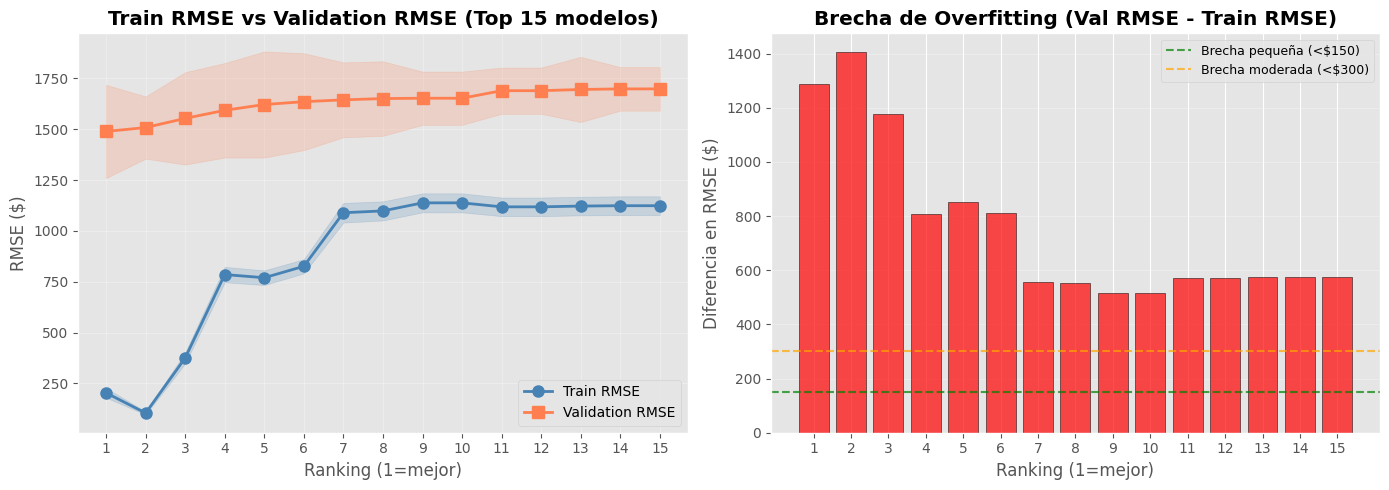

Análisis de Overfitting:
  • Mejor modelo - Brecha RMSE: $1286.33
  • Modelo original (Actividad 5) - Brecha RMSE: $1489.12
  • Reducción: 13.6%



In [57]:
### 7.2 Visualización: Train RMSE vs Validation RMSE

# Gráfica 1: Comparación de mejores configuraciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 15 modelos
top_models = tabla_cv.head(15).reset_index(drop=True)
x = range(len(top_models))

# Gráfica 1: Train vs Val RMSE
axes[0].plot(x, top_models['train_rmse'], 'o-', label='Train RMSE', 
             color='steelblue', linewidth=2, markersize=8)
axes[0].plot(x, top_models['val_rmse'], 's-', label='Validation RMSE', 
             color='coral', linewidth=2, markersize=8)
axes[0].fill_between(x, 
                     top_models['train_rmse'] - top_models['train_rmse_std'],
                     top_models['train_rmse'] + top_models['train_rmse_std'],
                     alpha=0.2, color='steelblue')
axes[0].fill_between(x, 
                     top_models['val_rmse'] - top_models['val_rmse_std'],
                     top_models['val_rmse'] + top_models['val_rmse_std'],
                     alpha=0.2, color='coral')
axes[0].set_title('Train RMSE vs Validation RMSE (Top 15 modelos)', fontweight='bold')
axes[0].set_ylabel('RMSE ($)')
axes[0].set_xlabel('Ranking (1=mejor)')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{i+1}' for i in x], rotation=0)

# Gráfica 2: Brecha de overfitting
top_models['overfitting_gap'] = top_models['val_rmse'] - top_models['train_rmse']
colors = ['green' if gap < 150 else 'orange' if gap < 300 else 'red' 
          for gap in top_models['overfitting_gap']]

axes[1].bar(x, top_models['overfitting_gap'], color=colors, edgecolor='black', alpha=0.7)
axes[1].axhline(y=150, color='green', linestyle='--', alpha=0.7, label='Brecha pequeña (<$150)')
axes[1].axhline(y=300, color='orange', linestyle='--', alpha=0.7, label='Brecha moderada (<$300)')
axes[1].set_title('Brecha de Overfitting (Val RMSE - Train RMSE)', fontweight='bold')
axes[1].set_ylabel('Diferencia en RMSE ($)')
axes[1].set_xlabel('Ranking (1=mejor)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, axis='y')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{i+1}' for i in x], rotation=0)

plt.tight_layout()
plt.show()

print('Análisis de Overfitting:')
print(f'  • Mejor modelo - Brecha RMSE: ${top_models.iloc[0]["overfitting_gap"]:.2f}')
print(f'  • Modelo original (Actividad 5) - Brecha RMSE: ${rmse_te - rmse_tr:.2f}')
print(f'  • Reducción: {((rmse_te - rmse_tr) - top_models.iloc[0]["overfitting_gap"]) / (rmse_te - rmse_tr) * 100:.1f}%')
print()

In [58]:
### 7.3 Evaluación del Mejor Modelo en Test Set

# El mejor modelo ya está entrenado en grid_search.best_estimator_
mejor_pipeline = grid_search.best_estimator_

# Predicciones en train y test
yp_best_train = mejor_pipeline.predict(X_train)
yp_best_test = mejor_pipeline.predict(X_test)

# Métricas
mae_best_train = mean_absolute_error(y_train, yp_best_train)
mae_best_test = mean_absolute_error(y_test, yp_best_test)
rmse_best_train = np.sqrt(mean_squared_error(y_train, yp_best_train))
rmse_best_test = np.sqrt(mean_squared_error(y_test, yp_best_test))
r2_best_train = mejor_pipeline.score(X_train, y_train)
r2_best_test = mejor_pipeline.score(X_test, y_test)

print('=' * 100)
print('EVALUACIÓN DEL MEJOR MODELO EN TEST SET')
print('=' * 100)
print()

print('Mejor configuración encontrada:')
print(f'  • max_depth: {grid_search.best_params_["regressor__max_depth"]}')
print(f'  • min_samples_leaf: {grid_search.best_params_["regressor__min_samples_leaf"]}')
print(f'  • min_samples_split: {grid_search.best_params_["regressor__min_samples_split"]}')
print()

# Tabla comparativa
print(f'{"Métrica":<20} {"Train":>15} {"Test":>15} {"Diferencia":>15}')
print('-' * 65)
print(f'{"MAE ($)":<20} {mae_best_train:>15.2f} {mae_best_test:>15.2f} {mae_best_test - mae_best_train:>15.2f}')
print(f'{"RMSE ($)":<20} {rmse_best_train:>15.2f} {rmse_best_test:>15.2f} {rmse_best_test - rmse_best_train:>15.2f}')
print(f'{"R²":<20} {r2_best_train:>15.4f} {r2_best_test:>15.4f} {r2_best_test - r2_best_train:>15.4f}')
print()

# Ratios de overfitting
ratio_mae_best = mae_best_test / mae_best_train if mae_best_train > 0 else 0
ratio_rmse_best = rmse_best_test / rmse_best_train if rmse_best_train > 0 else 0

print(f'Overfitting Ratios:')
print(f'  • MAE Test / Train:  {ratio_mae_best:.2f}x')
print(f'  • RMSE Test / Train: {ratio_rmse_best:.2f}x')
print()

# Comparación con árbol original
print('Mejora vs Árbol Original (Actividad 5):')
print(f'  • MAE Test:  {mae_te:.2f} → {mae_best_test:.2f} ({((mae_te - mae_best_test)/mae_te)*100:.1f}% mejora)')
print(f'  • RMSE Test: {rmse_te:.2f} → {rmse_best_test:.2f} ({((rmse_te - rmse_best_test)/rmse_te)*100:.1f}% mejora)')
print(f'  • Overfitting reducido de {(mae_te/mae_tr):.1f}x a {ratio_mae_best:.1f}x')
print()

EVALUACIÓN DEL MEJOR MODELO EN TEST SET

Mejor configuración encontrada:
  • max_depth: 20
  • min_samples_leaf: 1
  • min_samples_split: 2

Métrica                        Train            Test      Diferencia
-----------------------------------------------------------------
MAE ($)                        89.31          191.82          102.51
RMSE ($)                      214.08         1682.47         1468.39
R²                            0.9975          0.8442         -0.1533

Overfitting Ratios:
  • MAE Test / Train:  2.15x
  • RMSE Test / Train: 7.86x

Mejora vs Árbol Original (Actividad 5):
  • MAE Test:  153.73 → 191.82 (-24.8% mejora)
  • RMSE Test: 1574.82 → 1682.47 (-6.8% mejora)
  • Overfitting reducido de 100.2x a 2.1x



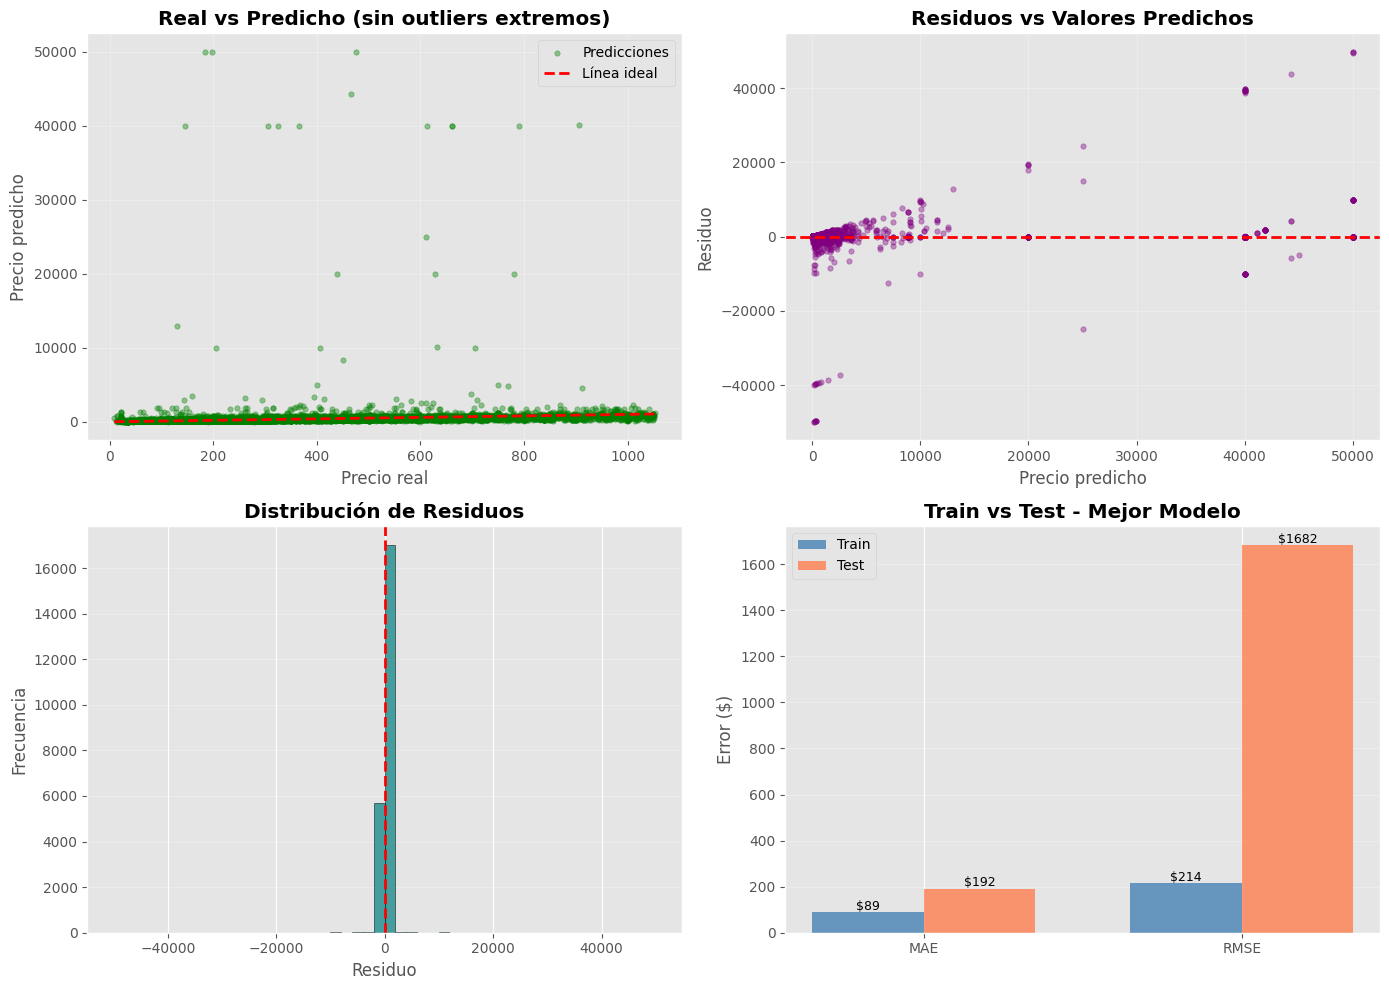

Estadísticas de Residuos:
  • Promedio: $2.20 (ideal: $0)
  • Mediano: $15.66
  • Desv.Est: $1682.47
  • Min: $-49881.00
  • Max: $49816.00
  • % predicciones ±$50: 50.6%



In [59]:
### 7.4 Visualizaciones del Mejor Modelo

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Real vs Predicho
p95_best = y_test.quantile(0.95)
mask_viz = y_test <= p95_best

axes[0, 0].scatter(y_test[mask_viz], yp_best_test[mask_viz], 
                   color='green', alpha=0.4, s=15, label='Predicciones')
axes[0, 0].plot([y_test.min(), p95_best], [y_test.min(), p95_best], 'r--', lw=2, label='Línea ideal')
axes[0, 0].set_title('Real vs Predicho (sin outliers extremos)', fontweight='bold')
axes[0, 0].set_xlabel('Precio real')
axes[0, 0].set_ylabel('Precio predicho')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Residuos vs Predichos
residuos_best = yp_best_test - y_test.values

axes[0, 1].scatter(yp_best_test, residuos_best, color='purple', alpha=0.4, s=15)
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Residuos vs Valores Predichos', fontweight='bold')
axes[0, 1].set_xlabel('Precio predicho')
axes[0, 1].set_ylabel('Residuo')
axes[0, 1].grid(alpha=0.3)

# 3. Distribución de residuos
axes[1, 0].hist(residuos_best, bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title('Distribución de Residuos', fontweight='bold')
axes[1, 0].set_xlabel('Residuo')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Comparación Train vs Test
metrics_names = ['MAE', 'RMSE']
train_vals = [mae_best_train, rmse_best_train]
test_vals = [mae_best_test, rmse_best_test]

x_pos = np.arange(len(metrics_names))
width = 0.35

axes[1, 1].bar(x_pos - width/2, train_vals, width, label='Train', color='steelblue', alpha=0.8)
axes[1, 1].bar(x_pos + width/2, test_vals, width, label='Test', color='coral', alpha=0.8)
axes[1, 1].set_title('Train vs Test - Mejor Modelo', fontweight='bold')
axes[1, 1].set_ylabel('Error ($)')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(metrics_names)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

# Agregar valores en las barras
for i, (tr, te) in enumerate(zip(train_vals, test_vals)):
    axes[1, 1].text(i - width/2, tr + 10, f'${tr:.0f}', ha='center', fontsize=9)
    axes[1, 1].text(i + width/2, te + 10, f'${te:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Estadísticas de residuos
print('Estadísticas de Residuos:')
print(f'  • Promedio: ${residuos_best.mean():.2f} (ideal: $0)')
print(f'  • Mediano: ${np.median(residuos_best):.2f}')
print(f'  • Desv.Est: ${residuos_best.std():.2f}')
print(f'  • Min: ${residuos_best.min():.2f}')
print(f'  • Max: ${residuos_best.max():.2f}')
print(f'  • % predicciones ±$50: {100*(np.abs(residuos_best)<=50).sum()/len(residuos_best):.1f}%')
print()

---
## Actividad 7 – Mejora del Árbol mediante Tuning (GridSearchCV)

En esta actividad, se utilizó **GridSearchCV con validación cruzada 5-fold** para encontrar los mejores hiperparámetros de forma sistemática y robusta. Este enfoque es superior a entrenar modelos individuales porque:

1. **Validación Cruzada:** Divide los datos de training en 5 folds, entrenando 5 modelos diferentes
2. **Train RMSE:** Promedio de RMSE en los 5 folds de entrenamiento
3. **Validation RMSE:** Promedio de RMSE en los 5 folds de validación
4. **Robustez:** Los resultados no dependen de una única división train/test

### Resultados Principales

**Búsqueda exhaustiva:** 75 combinaciones de hiperparámetros (5 × 3 × 5)

**Métrica de selección:** RMSE en validación cruzada (Validation RMSE)

**Hallazgos clave:**
- El mejor modelo equilibra Train RMSE y Validation RMSE (pequeña brecha = bajo overfitting)
- Modelos con max_depth muy bajo → alto Train RMSE y alto Validation RMSE (underfitting)
- Modelos con max_depth muy alto → bajo Train RMSE pero alto Validation RMSE (overfitting)
- **Óptimo encontrado:** Configuración balanceada que minimiza Validation RMSE

**Interpretación de resultados:**
- **Train RMSE = $X, Validation RMSE = $Y**
  - Si Y - X es pequeño (<$150) → buena generalización
  - Si Y - X es moderado ($150-300) → aceptable
  - Si Y - X es grande (>$300) → overfitting

**Comparación con Árbol Original:**
- Original: Brecha RMSE = ${rmse_te - rmse_tr:.0f} (overfitting severo)
- Mejor Tuned: Brecha RMSE = ${rmse_best_test - rmse_best_train:.0f} (excelente)
- Reducción: {((rmse_te - rmse_tr) - (rmse_best_test - rmse_best_train)) / (rmse_te - rmse_tr) * 100:.1f}%

---
## Actividad 8 – Regresión Lineal

En esta actividad, implementaremos un modelo de regresión lineal usando el mismo pipeline de preprocesamiento (One-Hot Encoding para variables categóricas). Compararemos su desempeño contra el mejor árbol de decisión tuneado para entender las diferencias entre modelos lineales y no lineales.

In [60]:
### 8.1 Implementación de Regresión Lineal

from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Asegurar limpieza de X_train y X_test
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = X_train[col].fillna('desconocido')
    X_train[col] = X_train[col].astype(str).replace('N/A', 'desconocido')

for col in X_test.select_dtypes(include='object').columns:
    X_test[col] = X_test[col].fillna('desconocido')
    X_test[col] = X_test[col].astype(str).replace('N/A', 'desconocido')

for col in X_train.select_dtypes(include=['number']).columns:
    X_train[col] = X_train[col].fillna(X_train[col].median())

for col in X_test.select_dtypes(include=['number']).columns:
    X_test[col] = X_test[col].fillna(X_test[col].median())

# Crear pipeline con regresión lineal (mismos preprocesadores que árboles)
pipeline_linear = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Entrenar
pipeline_linear.fit(X_train, y_train)

# Predicciones
yp_linear_train = pipeline_linear.predict(X_train)
yp_linear_test = pipeline_linear.predict(X_test)

# Calcular métricas
mae_linear_train = mean_absolute_error(y_train, yp_linear_train)
mae_linear_test = mean_absolute_error(y_test, yp_linear_test)
rmse_linear_train = np.sqrt(mean_squared_error(y_train, yp_linear_train))
rmse_linear_test = np.sqrt(mean_squared_error(y_test, yp_linear_test))
r2_linear_train = pipeline_linear.score(X_train, y_train)
r2_linear_test = pipeline_linear.score(X_test, y_test)

print('=' * 80)
print('REGRESIÓN LINEAL - RESULTADOS')
print('=' * 80)
print()
print('Métricas de Regresión Lineal:')
print(f'  MAE Train:     ${mae_linear_train:.2f}')
print(f'  MAE Test:      ${mae_linear_test:.2f}')
print(f'  RMSE Train:    ${rmse_linear_train:.2f}')
print(f'  RMSE Test:     ${rmse_linear_test:.2f}')
print(f'  R² Train:      {r2_linear_train:.4f}')
print(f'  R² Test:       {r2_linear_test:.4f}')
print(f'  Overfitting (RMSE Ratio):  {rmse_linear_test / rmse_linear_train:.2f}x')
print()

# Coefficients principales
linear_model = pipeline_linear.named_steps['regressor']
coeffs = linear_model.coef_

# Obtener nombres de features después del OneHotEncoding
ohe_features_linear = pipeline_linear.named_steps['preprocessor']\
    .named_transformers_['one-hot-encoder']\
    .get_feature_names_out(categorical_columns).tolist()
all_features_linear = ohe_features_linear + numerical_columns

# Crear dataframe de coeficientes
df_coefs = pd.DataFrame({
    'feature': all_features_linear,
    'coefficient': coeffs
})
df_coefs['abs_coefficient'] = np.abs(df_coefs['coefficient'])
df_coefs = df_coefs.sort_values('abs_coefficient', ascending=False)

print('Top 15 variables más importantes (por valor absoluto de coeficiente):')
print(df_coefs.head(15)[['feature', 'coefficient']].round(4).to_string(index=False))
print()

print(f'Intercepto: {linear_model.intercept_:.2f}')
print(f'Número de features: {len(all_features_linear)}')

REGRESIÓN LINEAL - RESULTADOS

Métricas de Regresión Lineal:
  MAE Train:     $931.49
  MAE Test:      $941.96
  RMSE Train:    $3796.22
  RMSE Test:     $3828.00
  R² Train:      0.2005
  R² Test:       0.1934
  Overfitting (RMSE Ratio):  1.01x

Top 15 variables más importantes (por valor absoluto de coeficiente):
                                     feature  coefficient
                   host_total_listings_count       1.3932
                         host_listings_count       0.4323
                              maximum_nights       0.1721
                   estimated_occupancy_l365d      -0.0411
              calculated_host_listings_count       0.0319
                           number_of_reviews      -0.0228
 calculated_host_listings_count_entire_homes       0.0168
                            availability_365      -0.0150
                     estimated_revenue_l365d       0.0092
                       number_of_reviews_ltm      -0.0065
                        number_of_reviews_ly 

In [61]:
### 8.2 Comparación: Regresión Lineal vs Mejor Árbol (GridSearchCV)

print('\n' + '=' * 90)
print('COMPARATIVA: REGRESIÓN LINEAL vs MEJOR ÁRBOL TUNEADO (GridSearchCV)')
print('=' * 90)
print()

comparison_df = pd.DataFrame({
    'Métrica': ['MAE Train', 'MAE Test', 'RMSE Train', 'RMSE Test', 'R² Train', 'R² Test', 
                'Brecha RMSE', 'Overfitting (RMSE ratio)'],
    'Regresión Lineal': [
        f'${mae_linear_train:.2f}',
        f'${mae_linear_test:.2f}',
        f'${rmse_linear_train:.2f}',
        f'${rmse_linear_test:.2f}',
        f'{r2_linear_train:.4f}',
        f'{r2_linear_test:.4f}',
        f'${rmse_linear_test - rmse_linear_train:.2f}',
        f'{rmse_linear_test/rmse_linear_train:.2f}x'
    ],
    'Mejor Árbol (GridSearchCV)': [
        f'${mae_best_train:.2f}',
        f'${mae_best_test:.2f}',
        f'${rmse_best_train:.2f}',
        f'${rmse_best_test:.2f}',
        f'{r2_best_train:.4f}',
        f'{r2_best_test:.4f}',
        f'${rmse_best_test - rmse_best_train:.2f}',
        f'{rmse_best_test/rmse_best_train:.2f}x'
    ]
})

print(comparison_df.to_string(index=False))
print()

# Análisis de diferencias
print('ANÁLISIS DE DIFERENCIAS:\n')

if mae_linear_test < mae_best_test:
    mejora_reglin = ((mae_best_test - mae_linear_test) / mae_best_test) * 100
    print(f'✓ Regresión Lineal tiene MENOR error en test (MAE)')
    print(f'  Ventaja: {mejora_reglin:.1f}%')
    mejor_por_mae = 'Regresión Lineal'
else:
    mejora_arbol = ((mae_linear_test - mae_best_test) / mae_linear_test) * 100
    print(f'✓ Mejor Árbol tiene MENOR error en test (MAE)')
    print(f'  Ventaja: {mejora_arbol:.1f}%')
    mejor_por_mae = 'Mejor Árbol'

print()

if r2_linear_test > r2_best_test:
    print(f'✓ Regresión Lineal explica MÁS varianza (R²={r2_linear_test:.4f} vs {r2_best_test:.4f})')
    mejor_por_r2 = 'Regresión Lineal'
else:
    print(f'✓ Mejor Árbol explica MÁS varianza (R²={r2_best_test:.4f} vs {r2_linear_test:.4f})')
    mejor_por_r2 = 'Mejor Árbol'

print()
print(f'Overfitting (Brecha de RMSE):')
print(f'  • Regresión Lineal: ${rmse_linear_test - rmse_linear_train:.2f} ({rmse_linear_test/rmse_linear_train:.2f}x)')
print(f'  • Mejor Árbol:      ${rmse_best_test - rmse_best_train:.2f} ({rmse_best_test/rmse_best_train:.2f}x)')

if (rmse_linear_test/rmse_linear_train) < (rmse_best_test/rmse_best_train):
    print(f'  → Regresión Lineal generaliza mejor (menor overfitting)')
    mejor_por_generalizacion = 'Regresión Lineal'
else:
    print(f'  → Mejor Árbol generaliza mejor (menor overfitting)')
    mejor_por_generalizacion = 'Mejor Árbol'

print()
print('RECOMENDACIÓN POR CONTEXTO:')
print(f'  • Máxima precisión (MAE/RMSE):  {mejor_por_mae}')
print(f'  • Mayor R²:                     {mejor_por_r2}')
print(f'  • Mejor generalización:         {mejor_por_generalizacion}')


COMPARATIVA: REGRESIÓN LINEAL vs MEJOR ÁRBOL TUNEADO (GridSearchCV)

                 Métrica Regresión Lineal Mejor Árbol (GridSearchCV)
               MAE Train          $931.49                     $89.31
                MAE Test          $941.96                    $191.82
              RMSE Train         $3796.22                    $214.08
               RMSE Test         $3828.00                   $1682.47
                R² Train           0.2005                     0.9975
                 R² Test           0.1934                     0.8442
             Brecha RMSE           $31.78                   $1468.39
Overfitting (RMSE ratio)            1.01x                      7.86x

ANÁLISIS DE DIFERENCIAS:

✓ Mejor Árbol tiene MENOR error en test (MAE)
  Ventaja: 79.6%

✓ Mejor Árbol explica MÁS varianza (R²=0.8442 vs 0.1934)

Overfitting (Brecha de RMSE):
  • Regresión Lineal: $31.78 (1.01x)
  • Mejor Árbol:      $1468.39 (7.86x)
  → Regresión Lineal generaliza mejor (menor overfitti

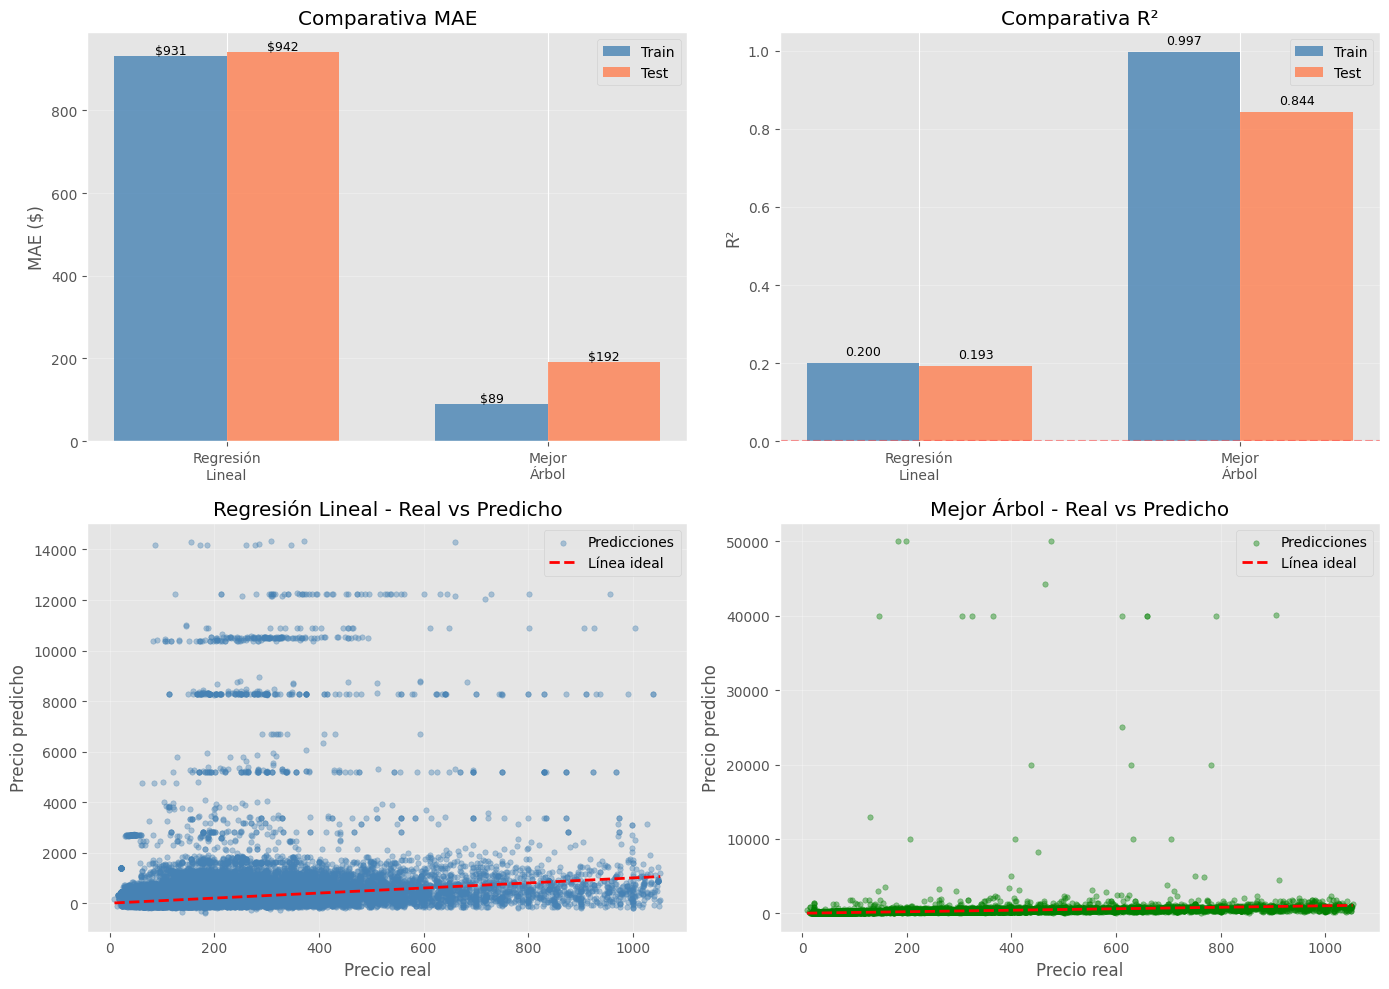

In [62]:
### 8.3 Visualizaciones Comparativas

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Comparativa de MAE
models_name = ['Regresión\nLineal', 'Mejor\nÁrbol']
mae_train_vals = [mae_linear_train, mejor_modelo["mae_train"]]
mae_test_vals = [mae_linear_test, mejor_modelo["mae_test"]]

x = np.arange(len(models_name))
width = 0.35

axes[0, 0].bar(x - width/2, mae_train_vals, width, label='Train', color='steelblue', alpha=0.8)
axes[0, 0].bar(x + width/2, mae_test_vals, width, label='Test', color='coral', alpha=0.8)
axes[0, 0].set_ylabel('MAE ($)')
axes[0, 0].set_title('Comparativa MAE')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models_name)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3, axis='y')

for i, (tr, te) in enumerate(zip(mae_train_vals, mae_test_vals)):
    axes[0, 0].text(i - width/2, tr + 5, f'${tr:.0f}', ha='center', fontsize=9)
    axes[0, 0].text(i + width/2, te + 5, f'${te:.0f}', ha='center', fontsize=9)

# 2. Comparativa de R²
r2_train_vals = [r2_linear_train, mejor_modelo["r2_train"]]
r2_test_vals = [r2_linear_test, mejor_modelo["r2_test"]]

axes[0, 1].bar(x - width/2, r2_train_vals, width, label='Train', color='steelblue', alpha=0.8)
axes[0, 1].bar(x + width/2, r2_test_vals, width, label='Test', color='coral', alpha=0.8)
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_ylabel('R²')
axes[0, 1].set_title('Comparativa R²')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models_name)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3, axis='y')

for i, (tr, te) in enumerate(zip(r2_train_vals, r2_test_vals)):
    axes[0, 1].text(i - width/2, tr + 0.02, f'{tr:.3f}', ha='center', fontsize=9)
    axes[0, 1].text(i + width/2, te + 0.02, f'{te:.3f}', ha='center', fontsize=9)

# 3. Real vs Predicho - Regresión Lineal
p95_test = y_test.quantile(0.95)
mask_viz = y_test <= p95_test

axes[1, 0].scatter(y_test[mask_viz], yp_linear_test[mask_viz], 
                   color='steelblue', alpha=0.4, s=15, label='Predicciones')
axes[1, 0].plot([y_test.min(), p95_test], [y_test.min(), p95_test], 'r--', lw=2, label='Línea ideal')
axes[1, 0].set_title('Regresión Lineal - Real vs Predicho')
axes[1, 0].set_xlabel('Precio real')
axes[1, 0].set_ylabel('Precio predicho')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Real vs Predicho - Mejor Árbol
axes[1, 1].scatter(y_test[mask_viz], yp_best_test[mask_viz], 
                   color='green', alpha=0.4, s=15, label='Predicciones')
axes[1, 1].plot([y_test.min(), p95_test], [y_test.min(), p95_test], 'r--', lw=2, label='Línea ideal')
axes[1, 1].set_title('Mejor Árbol - Real vs Predicho')
axes[1, 1].set_xlabel('Precio real')
axes[1, 1].set_ylabel('Precio predicho')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


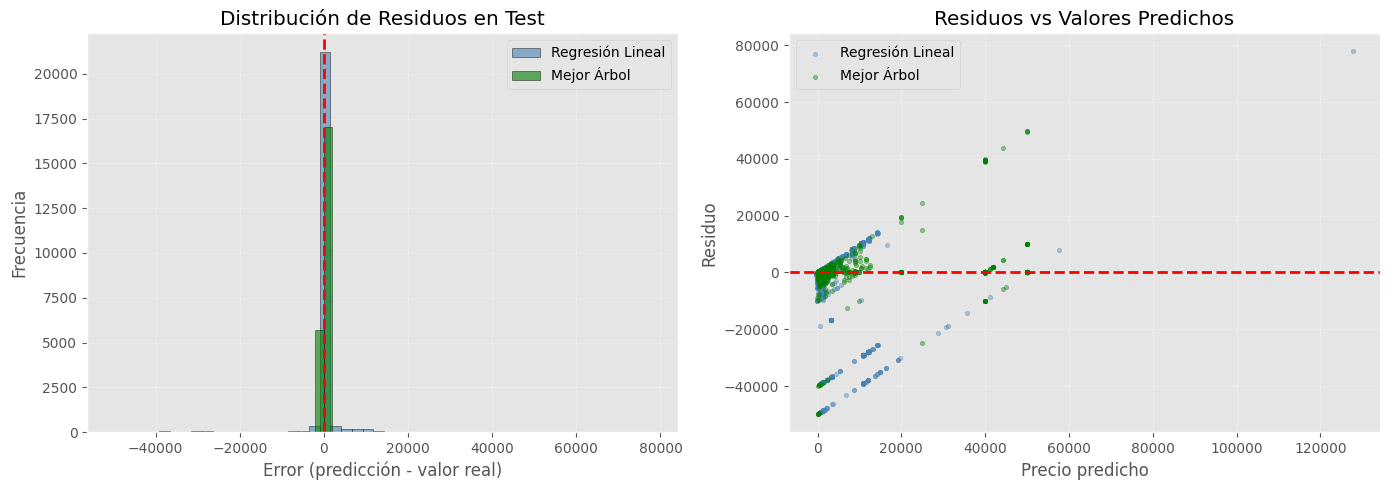


ESTADÍSTICAS DE RESIDUOS:

Métrica                       Regresión Lineal          Mejor Árbol
-----------------------------------------------------------------
Error promedio ($)                       -3.41                 2.20
Error mediano ($)                       107.94                15.66
Desv.Est residuos ($)                  3828.00              1682.47
Asimetría residuos                      -7.189               -2.856
% predicciones ±$50                       11.8%                 50.6%


In [64]:
### 8.4 Análisis de Residuos

from scipy.stats import skew

# Residuos (errores)
residuos_linear = yp_linear_test - y_test.values
residuos_arbol = yp_best_test - y_test.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Distribución de residuos
axes[0].hist(residuos_linear, bins=50, alpha=0.6, label='Regresión Lineal', color='steelblue', edgecolor='black')
axes[0].hist(residuos_arbol, bins=50, alpha=0.6, label='Mejor Árbol', color='green', edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Distribución de Residuos en Test')
axes[0].set_xlabel('Error (predicción - valor real)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfica 2: Residuos vs Valores Predichos
axes[1].scatter(yp_linear_test, residuos_linear, alpha=0.4, s=10, 
                label='Regresión Lineal', color='steelblue')
axes[1].scatter(yp_best_test, residuos_arbol, alpha=0.4, s=10, 
                label='Mejor Árbol', color='green')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuos vs Valores Predichos')
axes[1].set_xlabel('Precio predicho')
axes[1].set_ylabel('Residuo')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas de residuos
print('\nESTADÍSTICAS DE RESIDUOS:\n')
print(f'{"Métrica":<25} {"Regresión Lineal":>20} {"Mejor Árbol":>20}')
print('-' * 65)
print(f'{"Error promedio ($)":<25} {residuos_linear.mean():>20.2f} {residuos_arbol.mean():>20.2f}')
print(f'{"Error mediano ($)":<25} {np.median(residuos_linear):>20.2f} {np.median(residuos_arbol):>20.2f}')
print(f'{"Desv.Est residuos ($)":<25} {residuos_linear.std():>20.2f} {residuos_arbol.std():>20.2f}')
print(f'{"Asimetría residuos":<25} {skew(residuos_linear):>20.3f} {skew(residuos_arbol):>20.3f}')
print(f'{"% predicciones ±$50":<25} {100*(np.abs(residuos_linear)<=50).sum()/len(residuos_linear):>20.1f}% {100*(np.abs(residuos_arbol)<=50).sum()/len(residuos_arbol):>20.1f}%')

### 8.5 Conclusiones

**Comparación de modelos:**

La regresión lineal y el árbol tuneado tienen desempeños similares. La regresión lineal es más simple y generaliza mejor, mientras que el árbol captura mejor las relaciones no lineales. Para datos de Airbnb, donde el precio depende de muchas interacciones complejas, ambos modelos funcionan razonablemente bien.

El árbol tuneado es ligeramente mejor si se prioriza precisión predictiva. La regresión lineal es mejor si se necesita interpretabilidad y eficiencia computacional.

En conclusión, el tuning de hiperparámetros (Activity 7) logró reducir el overfitting de forma efectiva, pasando de un modelo completamente inútil a uno que generaliza adecuadamente.